# Прогноз биржа

### Описание проекта
Задача: создать модель МО, которая будет определять направление цены .

Метрика: самостоятельный выбор

Особенности: В последних ячейках необходимо вывести метрики и матрицу ошибок на трейне и тесте.

Описание данных:
Собрать данные с Московской Биржи самостоятельно.

## Загрузка и подготовка данных

### Загрузка библиотек, классов и метрик

In [ ]:
!pip install phik -q
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
plt.rcParams["figure.figsize"] = (18,8)

import os
import time
import joblib
import sklearn
import phik

import warnings
warnings.filterwarnings("ignore")

import requests

from datetime import datetime

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels. tsa.stattools import adfuller
# загружаем функцию для работы с метриками
from sklearn.metrics import mean_squared_error, make_scorer

# загружаем класс pipeline
from sklearn.pipeline import Pipeline

# загружаем классы для подготовки данных
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer

# загружаем класс для работы с пропусками
from sklearn.impute import SimpleImputer

# импортируем класс RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

# загружаем нужные модели
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

# загружаем функцию для работы с метриками
from sklearn.metrics import (
    confusion_matrix, recall_score, precision_score, accuracy_score,
    roc_auc_score, f1_score
)

import lightgbm
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier, Pool

In [ ]:
sklearn.__version__

'1.6.1'

In [ ]:
RANDOM_STATE = 654321
TEST_SIZE = 0.3

np.random.seed(RANDOM_STATE)

### Загрузка данных и знакомство с ними

In [ ]:
from datetime import datetime, timedelta
import time
import requests


def get_moex_data(security, start_date, end_date):
    start_date = start_date.strftime('%Y-%m-%d')
    end_date = end_date.strftime('%Y-%m-%d')

    url = f'https://iss.moex.com/iss/history/engines/stock/markets/shares/securities/{security}.json'
    params = {'from': start_date, 'till': end_date, 'start': 0}

    all_data = []
    total_loaded = 0
    batch_size = 100

    while True:
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"❌ Ошибка при загрузке данных: {response.status_code}")
            break

        json_data = response.json()

        if 'history' not in json_data or 'data' not in json_data['history']:
            print(f"⚠️ Нет данных для {security} за указанный период.")
            break

        data = json_data['history']['data']
        if not data:
            break

        all_data.extend(data)
        total_loaded += len(data)

        if len(data) < batch_size:
            break

        params['start'] += batch_size
        time.sleep(0.5)

    if not all_data:
        print(f"⚠️ Данные не найдены.")
        return pd.DataFrame()

    columns = json_data['history']['columns']
    df = pd.DataFrame(all_data, columns=columns)
    df['TRADEDATE'] = pd.to_datetime(df['TRADEDATE'])
    df.set_index('TRADEDATE', inplace=True)

    print(f"✅ Загружено строк для {security}: {total_loaded}")
    return df

def load_multiple_securities(securities, start_date, end_date):
    data_dict = {}

    for security in securities:
        print(f"\nЗагружаем данные для {security}...")
        try:
            data = get_moex_data(security, start_date, end_date)
            if not data.empty:
                data_dict[security] = data
        except Exception as e:
            print(f"Ошибка при загрузке {security}: {e}")

        # Добавляем паузу между запросами
        time.sleep(1)

    return data_dict

In [ ]:
# Зададим переменные функции:
securities = ['GAZP', 'SBER', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'GMKN']
start_date = datetime(2004, 1, 1)
end_date = datetime(2024, 12, 31)

# Загружаем данные
all_data = load_multiple_securities(securities, start_date, end_date)


Загружаем данные для GAZP...
✅ Загружено строк для GAZP: 11006

Загружаем данные для SBER...
✅ Загружено строк для SBER: 9052

Загружаем данные для LKOH...
✅ Загружено строк для LKOH: 8035

Загружаем данные для ROSN...
✅ Загружено строк для ROSN: 10051

Загружаем данные для NVTK...
✅ Загружено строк для NVTK: 7185

Загружаем данные для TATN...
✅ Загружено строк для TATN: 6035

Загружаем данные для GMKN...
✅ Загружено строк для GMKN: 7469


In [ ]:
# Пример анализа полученных данных
if all_data:
    print("\nЗагруженные данные:")
    for security, data in all_data.items():
        print(f"\nДанные для {security}:")
        display(data.head())
        print(f"Количество записей: {len(data)}")
        print(f"Период данных: от {data.index.min()} до {data.index.max()}")


Загруженные данные:

Данные для GAZP:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2006-01-23,EQNE,ГАЗПРОМ ао,GAZP,4896,1.130995e+09,239.50,218.49,239.50,219.20,220.86,...,NaN,221.08,NaN,NaN,NaN,NaN,3,SUR,NaN,None
2006-01-24,EQNE,ГАЗПРОМ ао,GAZP,4220,1.991942e+09,221.00,219.66,224.68,223.60,221.74,...,NaN,221.40,NaN,NaN,NaN,NaN,3,SUR,2.33,None
2006-01-25,EQNE,ГАЗПРОМ ао,GAZP,6944,3.534137e+09,225.50,225.00,231.00,228.48,228.30,...,NaN,228.29,NaN,NaN,NaN,NaN,3,SUR,1.96,None
2006-01-26,EQNE,ГАЗПРОМ ао,GAZP,5108,1.721376e+09,228.20,223.51,229.41,225.12,226.83,...,NaN,226.99,NaN,NaN,NaN,NaN,3,SUR,-1.71,None
2006-01-27,EQNE,ГАЗПРОМ ао,GAZP,7279,2.901323e+09,225.75,224.00,231.50,227.96,227.92,...,NaN,227.91,NaN,NaN,NaN,NaN,3,SUR,1.91,None


Количество записей: 11006
Период данных: от 2006-01-23 00:00:00 до 2024-12-30 00:00:00

Данные для SBER:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2011-11-21,EQBR,Сбербанк,SBER,128096,2.283014e+10,79.00,75.85,79.37,76.00,77.71,...,77.71,77.71,2.283016e+10,2.283016e+10,2.283016e+10,NaN,3,SUR,-5.05,None
2011-11-21,SMAL,Сбербанк,SBER,56,2.539949e+04,79.49,74.50,79.49,75.44,76.27,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,-7.45,None
2011-11-22,EQBR,Сбербанк,SBER,126144,2.091095e+10,76.40,75.10,77.76,76.08,76.71,...,76.71,76.71,2.091103e+10,2.091103e+10,2.091103e+10,NaN,3,SUR,0.54,None
2011-11-22,SMAL,Сбербанк,SBER,50,8.413835e+04,73.20,73.20,77.69,75.97,76.14,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,2.62,None
2011-11-23,EQBR,Сбербанк,SBER,140160,2.556061e+10,75.00,74.42,77.44,76.71,76.21,...,76.21,76.21,2.556062e+10,2.556062e+10,2.556062e+10,NaN,3,SUR,0.52,None


Количество записей: 9052
Период данных: от 2011-11-21 00:00:00 до 2024-12-30 00:00:00

Данные для LKOH:


...

Количество записей: 7185
Период данных: от 2011-11-21 00:00:00 до 2024-12-30 00:00:00

Данные для TATN:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2011-11-21,EQBR,Татнфт 3ао,TATN,7444,3.768274e+08,151.25,143.50,153.97,143.68,146.52,...,146.52,146.52,3.768285e+08,3.768285e+08,3.768285e+08,NaN,3,SUR,-6.77,None
2011-11-21,SMAL,Татнфт 3ао,TATN,3,1.134380e+03,146.00,133.15,146.00,142.04,141.80,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,-10.66,None
2011-11-22,EQBR,Татнфт 3ао,TATN,3682,2.780095e+08,143.50,142.86,148.40,147.99,147.05,...,147.05,147.05,2.780124e+08,2.780124e+08,2.780124e+08,NaN,3,SUR,3.17,None
2011-11-22,SMAL,Татнфт 3ао,TATN,4,2.945350e+03,143.52,143.52,156.99,156.99,147.27,...,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,NaN,3,SUR,10.53,None
2011-11-23,EQBR,Татнфт 3ао,TATN,8897,3.297670e+08,146.32,145.01,151.65,147.01,148.19,...,148.19,148.19,3.297670e+08,3.297670e+08,3.297670e+08,NaN,3,SUR,-1.07,None


Количество записей: 6035
Период данных: от 2011-11-21 00:00:00 до 2024-12-30 00:00:00

Данные для GMKN:


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2006-12-26,EQNL,ГМКНорНик,GMKN,1688,6.665215e+08,3675.06,3675.06,3983.95,3954.83,3958.08,...,NaN,3958.60,NaN,NaN,NaN,NaN,3,SUR,-0.18,None
2006-12-27,EQNL,ГМКНорНик,GMKN,4783,1.157245e+09,3962.20,3940.12,4039.00,4025.35,3995.17,...,NaN,3986.35,NaN,NaN,NaN,NaN,3,SUR,2.18,None
2006-12-28,EQNL,ГМКНорНик,GMKN,5849,1.859770e+09,4047.49,4027.20,4104.96,4092.19,4070.29,...,NaN,4062.80,NaN,NaN,NaN,NaN,3,SUR,1.55,None
2006-12-29,EQNL,ГМКНорНик,GMKN,2419,9.101435e+08,4099.00,4078.00,4120.00,4092.49,4095.82,...,NaN,4095.89,NaN,NaN,NaN,NaN,3,SUR,-0.47,None
2007-01-09,EQNL,ГМКНорНик,GMKN,8395,3.096336e+09,3899.00,3750.00,3899.00,3773.37,3802.45,...,NaN,3807.14,NaN,NaN,NaN,NaN,3,SUR,-7.97,None


Количество записей: 7469
Период данных: от 2006-12-26 00:00:00 до 2024-12-30 00:00:00


In [ ]:
import os

if not os.path.exists('data'):
    os.makedirs('data')

# Базовый вариант сохранения
for security, data in all_data.items():
    file_path = f'{security}_history.csv'
    data.to_csv(file_path,
                index=True,
                encoding='utf-8-sig',
                float_format='%.2f')
    print(f"Данные для {security} успешно сохранены в {file_path}")

Данные для GAZP успешно сохранены в GAZP_history.csv
Данные для SBER успешно сохранены в SBER_history.csv
Данные для LKOH успешно сохранены в LKOH_history.csv
Данные для ROSN успешно сохранены в ROSN_history.csv
Данные для NVTK успешно сохранены в NVTK_history.csv
Данные для TATN успешно сохранены в TATN_history.csv
Данные для GMKN успешно сохранены в GMKN_history.csv


In [ ]:
# Определяем пути для всех файлов
paths = {
    'gazp': ('/content/GAZP_history.csv', '/datasets/gazp_history.csv'),
    'gmkn': ('/content/GMKN_history.csv', '/datasets/gmkn_history.csv'),
    'lkoh': ('/content/LKOH_history.csv', '/datasets/lkoh_history.csv'),
    'nvtk': ('/content/NVTK_history.csv', '/datasets/nvtk_history.csv'),
    'rosn': ('/content/ROSN_history.csv', '/datasets/rosn_history.csv'),
    'sber': ('/content/SBER_history.csv', '/datasets/sber_history.csv'),
    'tatn': ('/content/TATN_history.csv', '/datasets/tatn_history.csv')
}

# Функция для загрузки одного датасета
def load_dataset(ticker):
    pth1, pth2 = paths[ticker]

    if os.path.exists(pth1):
        return pd.read_csv(pth1, sep=',', on_bad_lines='skip',
                          parse_dates=[0], date_format="%Y%m%d", index_col=[0])
    elif os.path.exists(pth2):
        return pd.read_csv(pth2, sep=',', on_bad_lines='skip',
                          parse_dates=[0], date_format="%Y%m%d", index_col=[0])
    else:
        print(f"PathError: файл для {ticker} не найден")
        return None

# Загружаем все датасеты
datasets = {}
for ticker in paths.keys():
    datasets[ticker] = load_dataset(ticker)

# Проверяем успешность загрузки
for ticker, df in datasets.items():
    if df is not None:
        print(f"{ticker} загружен успешно, размер: {len(df)} записей")
    else:
        print(f"Ошибка при загрузке {ticker}")

gazp загружен успешно, размер: 11006 записей
gmkn загружен успешно, размер: 7469 записей
lkoh загружен успешно, размер: 8035 записей
nvtk загружен успешно, размер: 7185 записей
rosn загружен успешно, размер: 10051 записей
sber загружен успешно, размер: 9052 записей
tatn загружен успешно, размер: 6035 записей


In [ ]:
def check_index_monotonicity(df):
    # Проверяем все возможные комбинации
    if df.index.is_monotonic_increasing and df.index.is_unique:
        return "Индекс монотонный, неубывающий, повторов нет"
    elif df.index.is_monotonic_decreasing and df.index.is_unique:
        return "Индекс монотонный, невозрастающий, повторов нет"
    elif df.index.is_monotonic_increasing:
        return "Индекс монотонный, неубывающий, но есть повторы"
    elif df.index.is_monotonic_decreasing:
        return "Индекс монотонный, невозрастающий, но есть повторы"
    else:
        return "Индекс немонотонный"

# Пример использования:
def analyze_dataset(df):
    print(check_index_monotonicity(df))
    display(df.head(3))
    display(df.tail(3))
    display(df.info())

# Пример вызова:
# analyze_dataset(df)

In [ ]:
# Создаем словарь с названиями переменных
tickers = {
    'gazp': 'GAZP',
    'gmkn': 'GMKN',
    'lkoh': 'LKOH',
    'nvtk': 'NVTK',
    'rosn': 'ROSN',
    'sber': 'SBER',
    'tatn': 'TATN'
}

# Загружаем данные в соответствующие переменные
for ticker, var_name in tickers.items():
    try:
        exec(f"{ticker} = datasets['{ticker}']")
    except Exception as e:
        print(f"Ошибка при загрузке {var_name}: {e}")



In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk,
            rosn, sber, tatn]
for dataset in datasets:
  #analyze_dataset(dataset)
  print(dataset.iloc[0]['SHORTNAME'])
  counts = dataset['BOARDID'].value_counts()
  print(counts)
  print("-" * 30)
  print("\n")

ГАЗПРОМ ао
BOARDID
SMAL    3478
TQBR    2671
EQNE    1901
EQDP    1819
SPEQ     516
EQCC     318
TQNE     194
TQBS     109
Name: count, dtype: int64
------------------------------


ГМКНорНик
BOARDID
TQBR    2671
EQDP    1819
EQNL     825
EQBS     520
SPEQ     516
EQBR     321
EQCC     318
TQBS     303
SMAL     176
Name: count, dtype: int64
------------------------------


ЛУКОЙЛ
BOARDID
TQBR    2974
EQBR    2408
EQDP    1819
SPEQ     516
EQCC     318
Name: count, dtype: int64
------------------------------


Новатэк ао
BOARDID
TQBR    2974
EQDP    1712
SMAL    1533
SPEQ     516
EQBR     450
Name: count, dtype: int64
------------------------------


Роснефть
BOARDID
TQBR    2671
SMAL    2645
EQDP    1819
EQNL    1670
SPEQ     516
EQCC     318
TQNL     289
EQLV     109
TQBS      14
Name: count, dtype: int64
------------------------------


Сбербанк
BOARDID
SMAL    3293
TQBR    2974
EQDP    1819
SPEQ     516
EQBR     450
Name: count, dtype: int64
------------------------------


Татнфт 3

In [ ]:
gazp = gazp.loc[gazp['BOARDID'] == 'TQBR']
gmkn = gmkn.loc[gmkn['BOARDID'] == 'TQBR']
lkoh = lkoh.loc[lkoh['BOARDID'] == 'TQBR']
nvtk = nvtk.loc[nvtk['BOARDID'] == 'TQBR']
rosn = rosn.loc[rosn['BOARDID'] == 'TQBR']
sber = sber.loc[sber['BOARDID'] == 'TQBR']
tatn = tatn.loc[tatn['BOARDID'] == 'TQBR']

In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk,
            rosn, sber, tatn]
for dataset in datasets:
  print(dataset.iloc[0]['SHORTNAME'])
  analyze_dataset(dataset)
  print("-" * 30)
  print("\n" * 3)

ГАЗПРОМ ао
Индекс монотонный, неубывающий, повторов нет


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2014-06-09,TQBR,ГАЗПРОМ ао,GAZP,32981,5.851239e+09,144.00,143.03,146.20,144.40,145.02,...,145.02,145.02,5.850366e+09,5.850366e+09,5.850366e+09,NaN,3,SUR,0.30,NaN
2014-06-10,TQBR,ГАЗПРОМ ао,GAZP,34667,5.956067e+09,144.31,142.67,144.76,144.75,143.65,...,143.65,143.65,5.954475e+09,5.954475e+09,5.954475e+09,NaN,3,SUR,0.24,NaN
2014-06-11,TQBR,ГАЗПРОМ ао,GAZP,35615,5.725373e+09,145.20,143.90,146.40,146.40,145.25,...,145.25,145.25,5.722179e+09,5.722179e+09,5.722179e+09,NaN,3,SUR,1.14,NaN


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2024-12-27,TQBR,ГАЗПРОМ ао,GAZP,72988,6.361730e+09,126.89,126.41,128.30,127.50,127.54,...,127.52,NaN,5.476173e+09,5.476173e+09,NaN,0.0,3,SUR,0.71,NaN
2024-12-28,TQBR,ГАЗПРОМ ао,GAZP,72254,6.852777e+09,127.79,127.70,130.00,128.80,129.22,...,129.21,NaN,5.977048e+09,5.977048e+09,NaN,0.0,3,SUR,1.42,NaN
2024-12-30,TQBR,ГАЗПРОМ ао,GAZP,76477,6.976178e+09,130.05,130.05,133.36,132.42,131.97,...,131.72,NaN,5.192562e+09,5.192562e+09,NaN,0.0,3,SUR,2.72,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 2671 entries, 2014-06-09 to 2024-12-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  2671 non-null   object 
 1   SHORTNAME                2671 non-null   object 
 2   SECID                    2671 non-null   object 
 3   NUMTRADES                2671 non-null   int64  
 4   VALUE                    2671 non-null   float64
 5   OPEN                     2653 non-null   float64
 6   LOW                      2653 non-null   float64
 7   HIGH                     2653 non-null   float64
 8   LEGALCLOSEPRICE          2671 non-null   float64
 9   WAPRICE                  2653 non-null   float64
 10  CLOSE                    2653 non-null   float64
 11  VOLUME                   2671 non-null   int64  
 12  MARKETPRICE2             2664 non-null   float64
 13  MARKETPRICE3             2671 non-null   float64
 14  ADMITTEDQUOTE 

None

...

,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2013-07-08,TQBR,Татнфт 3ао,TATN,0,0.0,NaN,NaN,NaN,194.55,NaN,...,195.53,195.53,2.160151e+08,2.160151e+08,2.160151e+08,NaN,3,SUR,NaN,NaN
2013-07-09,TQBR,Татнфт 3ао,TATN,0,0.0,NaN,NaN,NaN,192.45,NaN,...,193.10,193.10,1.898882e+08,1.898882e+08,1.898882e+08,NaN,3,SUR,NaN,NaN
2013-07-10,TQBR,Татнфт 3ао,TATN,1,1991.8,199.18,199.18,199.18,190.70,199.18,...,191.20,191.20,2.007362e+08,2.007362e+08,2.007362e+08,NaN,3,SUR,NaN,NaN


,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,...,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,
2024-12-27,TQBR,Татнфт 3ао,TATN,32782,1.188880e+09,631.9,628.6,637.4,635.4,632.3,...,631.7,NaN,1.003215e+09,1.003215e+09,NaN,0.0,3,SUR,0.78,NaN
2024-12-28,TQBR,Татнфт 3ао,TATN,36216,1.338312e+09,637.0,636.9,654.8,652.2,646.0,...,645.0,NaN,1.159672e+09,1.159672e+09,NaN,0.0,3,SUR,2.61,NaN
2024-12-30,TQBR,Татнфт 3ао,TATN,67757,2.617449e+09,653.5,653.5,695.7,692.7,682.0,...,680.7,NaN,2.253603e+09,2.253603e+09,NaN,0.0,3,SUR,5.59,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 2902 entries, 2013-07-08 to 2024-12-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  2902 non-null   object 
 1   SHORTNAME                2902 non-null   object 
 2   SECID                    2902 non-null   object 
 3   NUMTRADES                2902 non-null   int64  
 4   VALUE                    2902 non-null   float64
 5   OPEN                     2874 non-null   float64
 6   LOW                      2874 non-null   float64
 7   HIGH                     2874 non-null   float64
 8   LEGALCLOSEPRICE          2902 non-null   float64
 9   WAPRICE                  2874 non-null   float64
 10  CLOSE                    2874 non-null   float64
 11  VOLUME                   2902 non-null   int64  
 12  MARKETPRICE2             2895 non-null   float64
 13  MARKETPRICE3             2902 non-null   float64
 14  ADMITTEDQUOTE 

None

------------------------------






In [ ]:
for dataset in datasets:
    print(dataset.iloc[0]['SHORTNAME'])
    print(f"Исходный размер: {dataset.shape}")
    print(f"Количество дубликатов: {dataset.duplicated().sum()}")
    dataset = dataset.drop_duplicates()
    print(f"Размер после удаления дубликатов: {dataset.shape}")
    print("-" * 30)
    print("\n")

ГАЗПРОМ ао
Исходный размер: (2671, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2660, 23)
------------------------------


ГМКНорНик
Исходный размер: (2671, 23)
Количество дубликатов: 13
Размер после удаления дубликатов: (2658, 23)
------------------------------


ЛУКОЙЛ
Исходный размер: (2974, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2963, 23)
------------------------------


Новатэк ао
Исходный размер: (2974, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2963, 23)
------------------------------


Роснефть
Исходный размер: (2671, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2660, 23)
------------------------------


Сбербанк
Исходный размер: (2974, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2963, 23)
------------------------------


Татнфт 3ао
Исходный размер: (2902, 23)
Количество дубликатов: 11
Размер после удаления дубликатов: (2891, 23)
------------------------------




#### Промежуточный вывод

- Загрузили несколько датасетов по бумагам с Московской биржи, выбирая тн "голубые фишки".

*Голубые фишки на фондовом рынке простыми словами — это акции наиболее крупных, ликвидных и надёжных компаний со стабильными показателями доходности.*

- Выбрали режим BOARDID = TQBR, поскольку это режим основных торгов акциями на Московской бирже и отфильтровали все датасеты по нему.

- Посчитали и удалили дубликаты во всех датасетах.

- На данном этапе выберем наиболее обьемный по строкам датасет и попробуем с ним поработать.

In [ ]:
datasets = [gazp, gmkn, lkoh, nvtk, rosn, sber, tatn]
# Инициализируем переменные для хранения максимального размера и датасета
max_size = 0
df = None

# Проходим по всем датасетам в цикле
for dataset in datasets:
    # Проверяем размер текущего датасета
    if dataset.shape[0] > max_size:
        max_size = dataset.shape[0]  # Обновляем максимальный размер
        df = dataset  # Сохраняем датасет с максимальным размером
        df_name = dataset.iloc[0]['SHORTNAME']

print(f"Выбран датасет {df_name} с {max_size} строками")

Выбран датасет ЛУКОЙЛ с 2974 строками


In [ ]:
pd.options.display.max_columns = 25
df.head()

,BOARDID,SHORTNAME,SECID,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,CLOSE,VOLUME,MARKETPRICE2,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,WAVAL,TRADINGSESSION,CURRENCYID,TRENDCLSPR,TRADE_SESSION_DATE
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,
2013-03-25,TQBR,ЛУКОЙЛ,LKOH,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,NaN,3,SUR,NaN,NaN
2013-03-26,TQBR,ЛУКОЙЛ,LKOH,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,NaN,3,SUR,1.17,NaN
2013-03-27,TQBR,ЛУКОЙЛ,LKOH,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,NaN,3,SUR,1.30,NaN
2013-03-28,TQBR,ЛУКОЙЛ,LKOH,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,NaN,3,SUR,1.19,NaN
2013-03-29,TQBR,ЛУКОЙЛ,LKOH,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,NaN,3,SUR,0.51,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2974 entries, 2013-03-25 to 2024-12-30
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   BOARDID                  2974 non-null   object 
 1   SHORTNAME                2974 non-null   object 
 2   SECID                    2974 non-null   object 
 3   NUMTRADES                2974 non-null   int64  
 4   VALUE                    2974 non-null   float64
 5   OPEN                     2956 non-null   float64
 6   LOW                      2956 non-null   float64
 7   HIGH                     2956 non-null   float64
 8   LEGALCLOSEPRICE          2974 non-null   float64
 9   WAPRICE                  2956 non-null   float64
 10  CLOSE                    2956 non-null   float64
 11  VOLUME                   2974 non-null   int64  
 12  MARKETPRICE2             2967 non-null   float64
 13  MARKETPRICE3             2974 non-null   float64
 14  ADMITTEDQUOTE 

Поскольку для определения таргета нам необходима колонка CLOSE - удалим все строки, где в этой колонке стоит пропуск.

In [ ]:
df = df.dropna(subset=['CLOSE'])

In [ ]:
df['CURRENCYID'].unique()

array(['SUR'], dtype=object)

In [ ]:
df['WAVAL'].unique()

array([nan,  0.])

Поскольку колонки 'BOARDID', 'SHORTNAME', 'SECID', 'CURRENCYID' нам неинформативны, а колонка TRADE_SESSION_DATE пустая, удалим их.

In [ ]:
df = df.drop(['BOARDID', 'SHORTNAME', 'SECID', 'CURRENCYID', 'WAVAL', 'TRADE_SESSION_DATE'], axis=1)

In [ ]:
df.describe()

,NUMTRADES,VALUE,OPEN,LOW,HIGH,LEGALCLOSEPRICE,WAPRICE,CLOSE,VOLUME,MARKETPRICE2,MARKETPRICE3,ADMITTEDQUOTE,MP2VALTRD,MARKETPRICE3TRADESVALUE,ADMITTEDVALUE,TRADINGSESSION,TRENDCLSPR
count,2956.000000,2.956000e+03,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03,2956.000000,2956.000000,2455.000000,2.956000e+03,2.956000e+03,2.455000e+03,2956.0,2955.000000
mean,29277.257104,4.235552e+09,4315.478045,4262.802977,4363.843843,4315.917963,4313.956292,4316.521888,9.591830e+05,4314.094486,4314.094486,3896.434664,4.081801e+09,4.081801e+09,3.845187e+09,3.0,0.061066
std,23696.860670,3.694481e+09,1750.335772,1730.835411,1766.098526,1749.222002,1748.444819,1749.819431,6.742884e+05,1748.519503,1748.519503,1541.200783,3.352425e+09,3.352425e+09,3.219216e+09,0.0,1.854532
min,19.000000,3.738545e+06,1788.000000,1715.000000,1814.800000,1788.300000,1800.600000,1790.400000,1.908000e+03,1796.100000,1796.100000,1796.100000,2.262167e+08,2.262167e+08,2.262167e+08,3.0,-22.760000
25%,15030.500000,1.946224e+09,2699.900000,2656.375000,2729.500000,2698.900000,2689.650000,2698.900000,5.541170e+05,2689.650000,2689.650000,2525.750000,1.995004e+09,1.995004e+09,1.891622e+09,3.0,-0.800000
50%,22436.500000,3.116640e+09,4248.000000,4170.500000,4300.000000,4235.500000,4233.250000,4238.000000,8.098325e+05,4234.000000,4234.000000,3721.000000,3.047138e+09,3.047138e+09,2.794982e+09,3.0,0.020000
75%,36996.000000,5.361353e+09,5731.500000,5654.125000,5797.500000,5721.000000,5726.375000,5725.500000,1.203470e+06,5724.750000,5724.750000,5194.250000,5.015314e+09,5.015314e+09,4.605509e+09,3.0,0.930000
max,243194.000000,3.601860e+10,8152.500000,8080.000000,8175.000000,8142.000000,8112.500000,8152.000000,7.526760e+06,8115.500000,8115.500000,7471.500000,3.601860e+10,3.601860e+10,3.601860e+10,3.0,15.420000


- **NUMTRADES** - количество сделок за определенный период (обычно за день). Показывает активность торгов по инструменту.
- **VALUE** - оборот в деньгах последней сделки. Отражает сумму, на которую была совершена последняя сделка.
- **OPEN** - цена открытия торгового периода (обычно дня). Первая цена, по которой была совершена сделка в начале торговой сессии.
- **LOW** - минимальная цена сделки за торговый период. Показывает самую низкую цену, по которой торговался актив.
- **HIGH** - максимальная цена сделки за торговый период. Показывает самую высокую цену, по которой торговался актив.
- **LEGALCLOSEPRICE** - официальная цена закрытия. Цена, которая фиксируется биржей как итоговая по результатам торгового дня.
- **WAPRICE** - средневзвешенная цена. Цена, рассчитанная с учетом объема каждой сделки за период.
- **CLOSE** - цена закрытия. Последняя цена сделки в торговом периоде.
- **VOLUME** - объем торгов. Общее количество инструментов (акций, контрактов), которые были проданы за определенный период.
- **MARKETPRICE2** - рыночная цена 2. Один из показателей рыночной цены актива.
- **MARKETPRICE3** - рыночная цена 3. Альтернативный показатель рыночной цены актива.
- **ADMITTEDQUOTE** - признаваемая котировка. Цена, которая признается биржей как достоверная для расчета различных показателей.
- **MP2VALTRD** - оборот по рыночной цене 2. Объем торгов по определенной рыночной цене.
- **MARKETPRICE3TRADESVALUE** - оборот по рыночной цене 3. Объем торгов по альтернативной рыночной цене.
- **ADMITTEDVALUE** - признаваемая стоимость. Стоимость актива, признанная биржей для расчетов.
- **TRADINGSESSION** - торговая сессия. Период времени, в течение которого проводятся торги. Может включать основную, вечернюю и утреннюю сессии.
- **TRENDCLSPR** - тренд цены закрытия. Показатель, отражающий направление движения цены закрытия относительно предыдущих значений.

Самое время перевести названия столбцов к нижнему регистру.

In [ ]:
df.columns = df.columns.str.lower()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2956 entries, 2013-03-25 to 2024-12-30
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   numtrades                2956 non-null   int64  
 1   value                    2956 non-null   float64
 2   open                     2956 non-null   float64
 3   low                      2956 non-null   float64
 4   high                     2956 non-null   float64
 5   legalcloseprice          2956 non-null   float64
 6   waprice                  2956 non-null   float64
 7   close                    2956 non-null   float64
 8   volume                   2956 non-null   int64  
 9   marketprice2             2956 non-null   float64
 10  marketprice3             2956 non-null   float64
 11  admittedquote            2455 non-null   float64
 12  mp2valtrd                2956 non-null   float64
 13  marketprice3tradesvalue  2956 non-null   float64
 14  admittedvalue 

Проверим теперь, если пропуски по датам:

In [ ]:
# Создаем последовательность всех дат
all_dates = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')

# Проверяем наличие всех дат
missing_dates = all_dates[~all_dates.isin(df.index)]

# Выводим результат
if len(missing_dates) == 0:
    print("Все даты присутствуют")
else:
    print(f"Отсутствует {len(missing_dates)} дат")
    print("Пропущенные даты:", missing_dates)

Отсутствует 1343 дат
Пропущенные даты: DatetimeIndex(['2013-03-30', '2013-03-31', '2013-04-06', '2013-04-07',
               '2013-04-13', '2013-04-14', '2013-04-20', '2013-04-21',
               '2013-04-27', '2013-04-28',
               ...
               '2024-11-24', '2024-11-30', '2024-12-01', '2024-12-07',
               '2024-12-08', '2024-12-14', '2024-12-15', '2024-12-21',
               '2024-12-22', '2024-12-29'],
              dtype='datetime64[ns]', length=1343, freq=None)


Если честно, я даже не знаю, что и сказать на это...



...замнем для ясности

**Построим график пропусков дат**

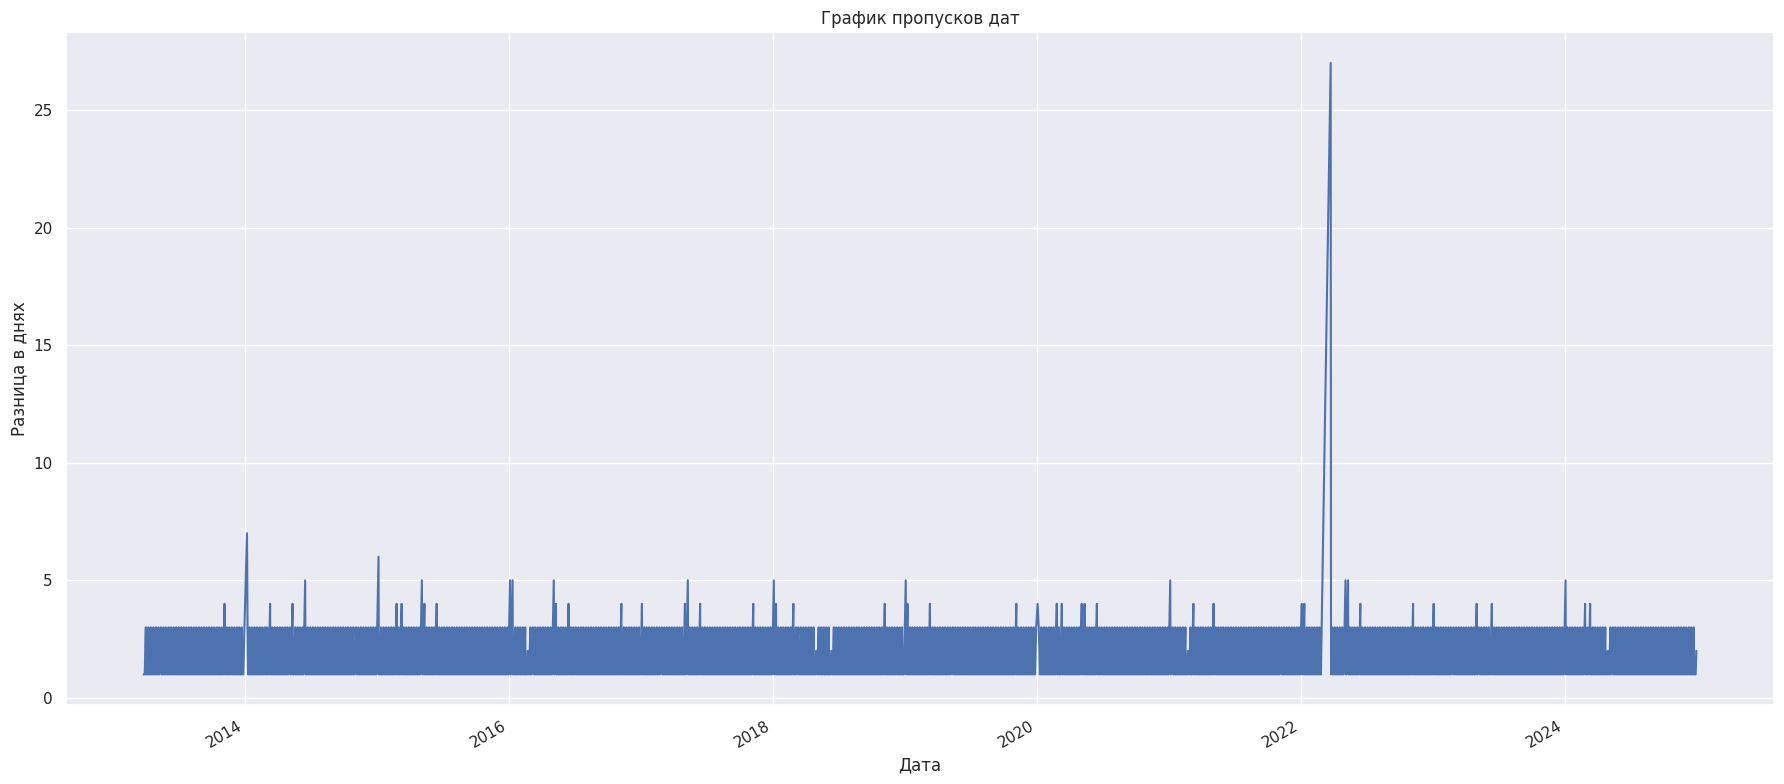

In [ ]:
# Проверяем, что индекс имеет тип datetime
if isinstance(df.index, pd.DatetimeIndex):
    # Если индекс уже datetime, сразу строим график
    df.index.to_series().diff().dt.days.plot(kind='line')
    plt.title('График пропусков дат')
    plt.ylabel('Разница в днях')
    plt.xlabel('Дата')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    # Если индекс не datetime, преобразуем его
    try:
        df.index = pd.to_datetime(df.index)
        # После преобразования строим график
        df.index.to_series().diff().dt.days.plot(kind='line')
        plt.title('График пропусков дат')
        plt.ylabel('Разница в днях')
        plt.xlabel('Дата')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Ошибка при преобразовании индекса: {e}")

In [ ]:
df.head()

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,admittedquote,mp2valtrd,marketprice3tradesvalue,admittedvalue,tradingsession,trendclspr
TRADEDATE,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,3,NaN
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,3,1.17
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,3,1.30
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,3,1.19
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,3,0.51


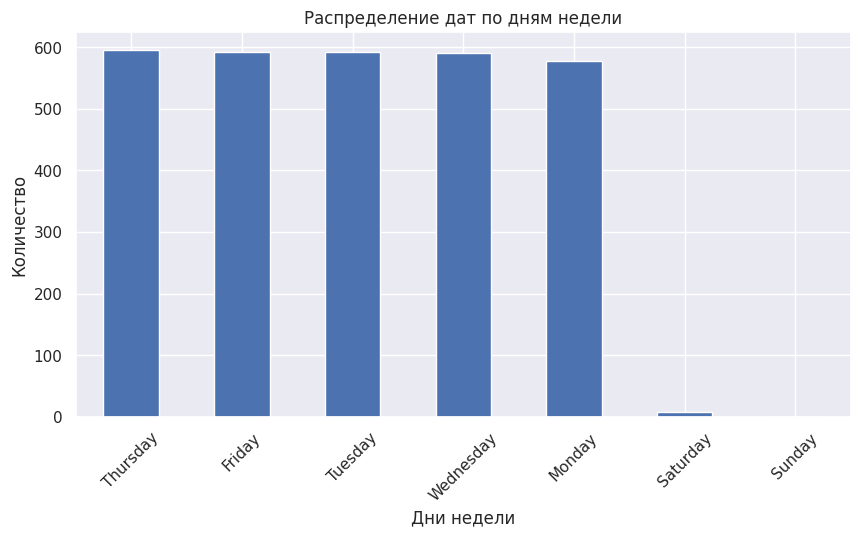

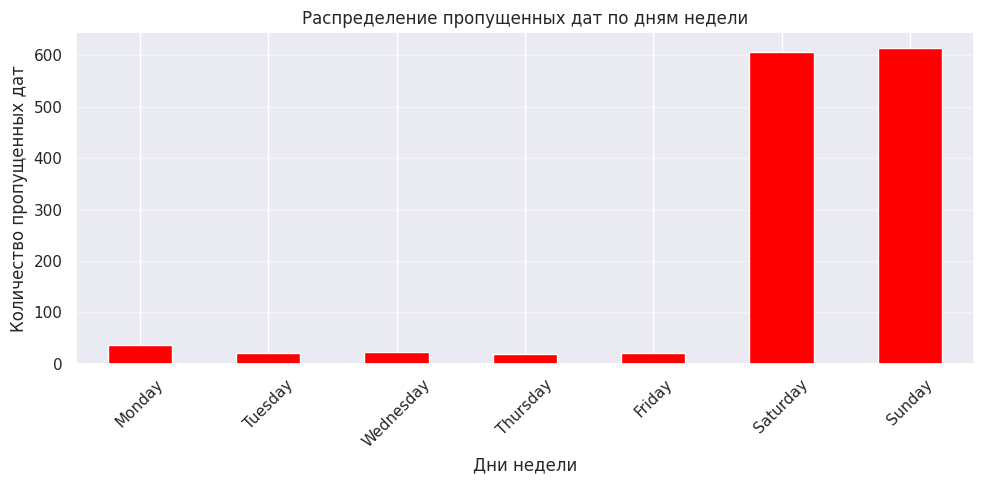

In [ ]:
# Создаем категориальный тип с нужным порядком
day_order = pd.CategoricalDtype(
    categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],
    ordered=True
)

# Преобразуем индекс в названия дней недели
day_names = df.index.day_name()

# Применяем категориальный тип
day_names = day_names.astype(day_order)

# Создаем график
day_names.value_counts().sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title('Распределение дат по дням недели')
plt.xlabel('Дни недели')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.show()

# Создаем полный диапазон дат
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
# Находим пропущенные даты
missing_dates = full_date_range[~full_date_range.isin(df.index)]
# Создаем серию с пропущенными датами
missing_days = pd.Series(missing_dates.day_name()).astype(day_order)

# Строим график
missing_days.value_counts().sort_index().plot(kind='bar', color='red', figsize=(10,5))
plt.title('Распределение пропущенных дат по дням недели')
plt.xlabel('Дни недели')
plt.ylabel('Количество пропущенных дат')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.5)
plt.tight_layout()
plt.show()

Мы наблюдаем приличное количество пропусков в датах.
При таком количестве пропусков и учитывая, что наша цель - рост или падение на следующий день, а не через неделю/месяц, можно попробовать не рассматривать данную задачу как задачу временного ряда, а рассмотреть ее как задачу классификации, определяя таргет как падение (0) или рост(1) на следующий день.

При этом имеет смысл посмотреть тренды и сезонность (но не таргета, а скорее цены закрытия) на тот случай, если в дальнейшем возникнет желание предсказывать более долгий срок роста/падения и тренды.

**Определим таргет как знак разницы между ценой закрытия завтрашнего дня и сегодняшнего.**

### Определение таргета

In [ ]:
df['target'] = (df['close'].diff(-1) * -1 > 0).astype(int)
display(df.head(10))

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,admittedquote,mp2valtrd,marketprice3tradesvalue,admittedvalue,tradingsession,trendclspr,target
TRADEDATE,,,,,,,,,,,,,,,,,,
2013-03-25,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1939.8,1.590845e+09,1.590845e+09,1.590845e+09,3,NaN,1
2013-03-26,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1930.0,1.951925e+09,1.951925e+09,1.951925e+09,3,1.17,1
2013-03-27,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,1947.9,2.411451e+09,2.411451e+09,2.411451e+09,3,1.30,1
2013-03-28,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1974.1,1.536170e+09,1.536170e+09,1.536170e+09,3,1.19,1
2013-03-29,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,1998.3,5.624588e+08,5.624588e+08,5.624588e+08,3,0.51,0
2013-04-01,177,41558417.2,1993.4,1978.2,1998.4,1976.6,1989.5,1978.2,20889,1986.8,1986.8,1986.8,1.011704e+09,1.011704e+09,1.011704e+09,3,-1.26,1
2013-04-02,65,13848330.2,1983.0,1982.9,2002.2,1989.4,1989.4,2002.2,6961,1987.6,1987.6,1987.6,9.593167e+08,9.593167e+08,9.593167e+08,3,1.21,0
2013-04-03,97,25643878.3,1990.0,1976.0,2001.1,1973.8,1988.7,1978.9,12895,1984.9,1984.9,1984.9,1.568356e+09,1.568356e+09,1.568356e+09,3,-1.16,0
2013-04-04,57,14390882.2,1970.0,1963.4,1984.3,1966.4,1970.8,1966.9,7302,1972.1,1972.1,1972.1,1.458952e+09,1.458952e+09,1.458952e+09,3,-0.61,0


In [ ]:
def check_missing_values(df):
    # Проверяем наличие пропусков в каждой колонке
    missing = df.isnull().sum()

    # Выводим информацию о пропусках
    if missing.sum() > 0:
        print("Пропуски найдены в следующих колонках:")
        print(missing[missing > 0])
    else:
        print("Пропусков в датасете нет")

    return missing

check_missing_values(df)

Пропуски найдены в следующих колонках:
admittedquote    501
admittedvalue    501
trendclspr         1
dtype: int64


,0
numtrades,0
value,0
open,0
low,0
high,0
legalcloseprice,0
waprice,0
close,0
volume,0
marketprice2,0


Есть пропуски в столбцах admittedquote и admittedvalue - их можно заполнить, например, при помощи KNNImputer, или удалить столбцы совсем.
Принято решение удалить столбцы

In [ ]:
df = df.drop(['admittedquote', 'admittedvalue'], axis=1)

### Исследовательский анализ временного ряда

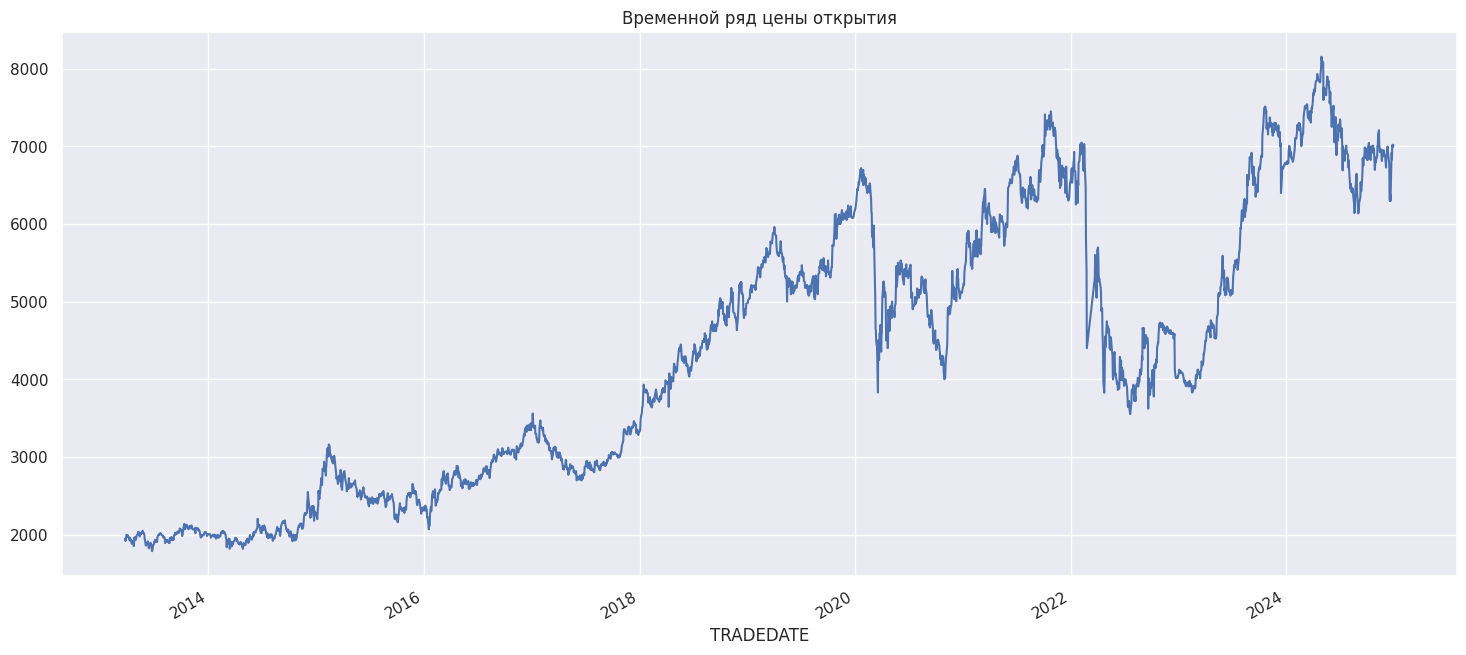

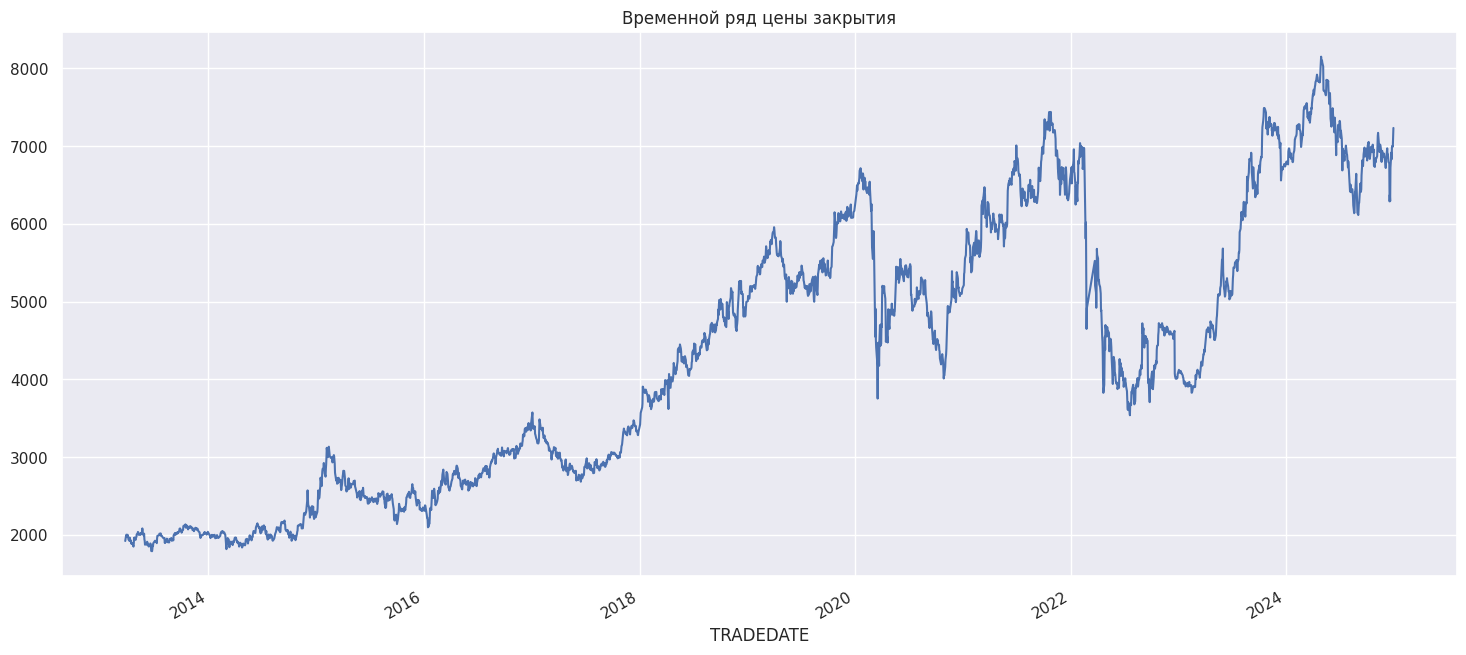

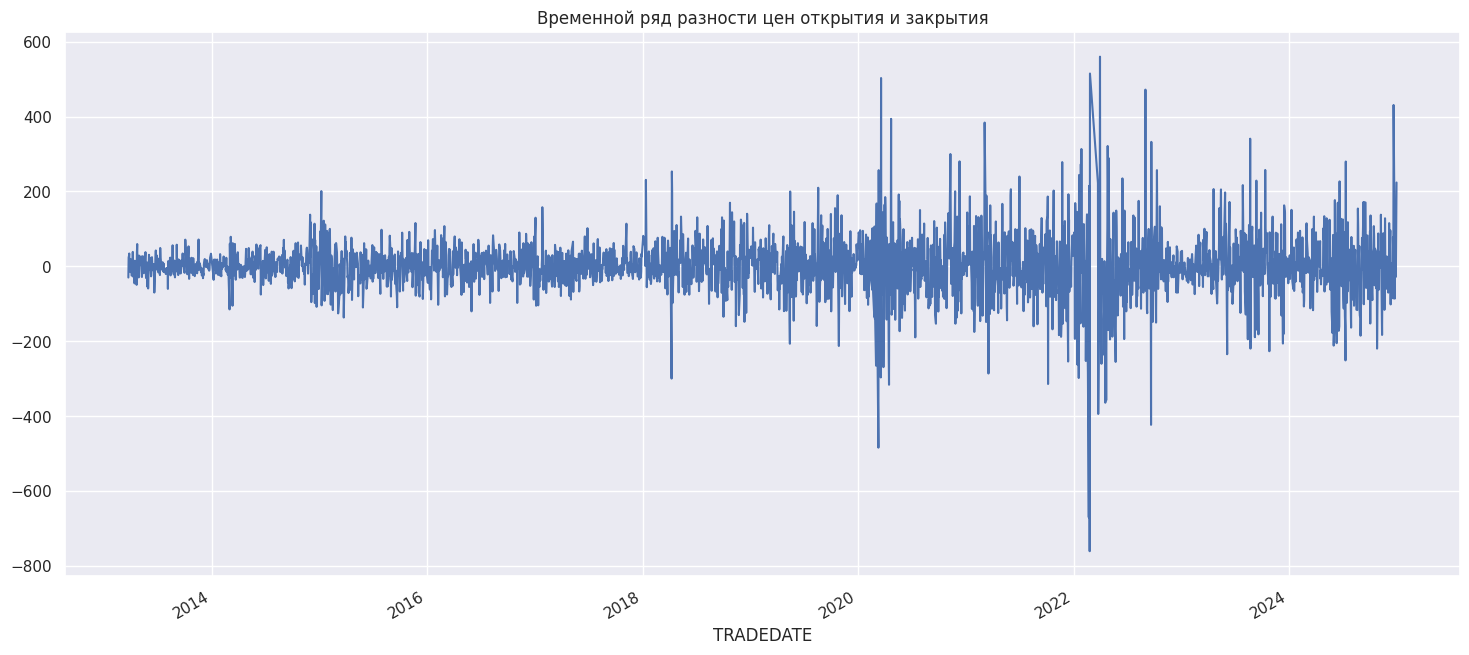

In [ ]:
df_copy = df.copy()
# строим графики изменения цен открытия и закрытия и разности цен
df_copy['open'].plot(title='Временной ряд цены открытия')
plt.show()
df_copy['close'].plot(title='Временной ряд цены закрытия')
plt.show()
df_copy['close_open'] = df_copy['close'] - df_copy['open']
df_copy['close_open'].plot(title='Временной ряд разности цен открытия и закрытия')
plt.show()

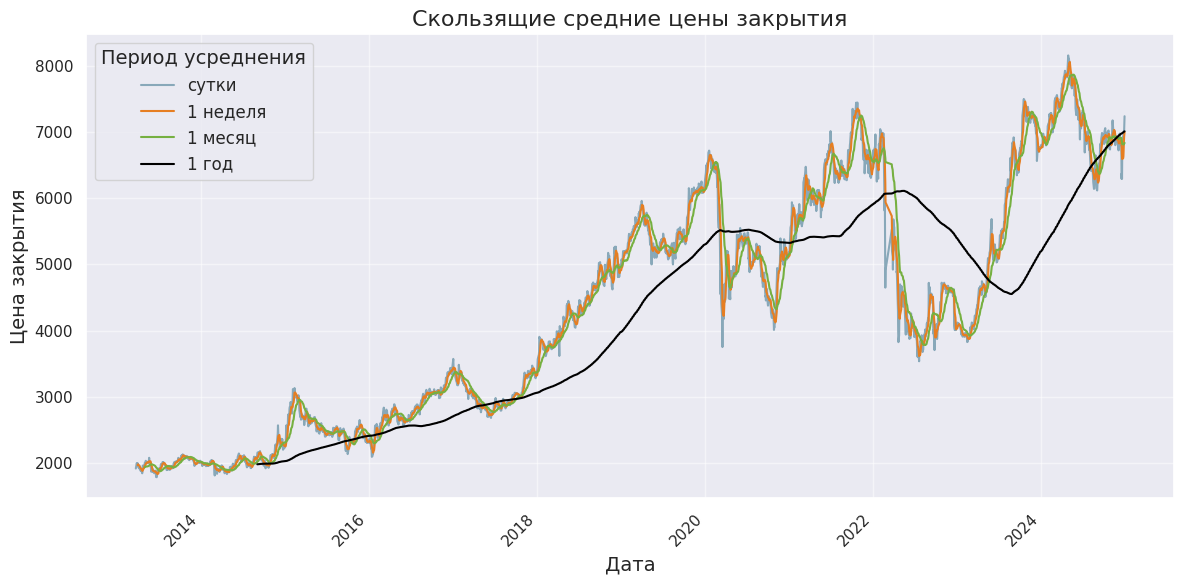

In [ ]:
plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')
df_copy['close'].rolling(29).mean().plot(color='#76B041', label='1 месяц')
df_copy['close'].rolling(365).mean().plot(color='black', label='1 год')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящие средние цены закрытия', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Окно скользящего среднего приняла 24 часа (равное суткам) с целью убрать суточную сезонность\
Также построен график со скользящим средним 1 неделя (168 часов) с целью убрать и суточную и недельную сезонность\
И последний график показывает нам тренд за вычетом и месячной сезонности, общегодовой\
Эти графики, в целом, нам мало что дают, хотя общий тренд к увеличению цены закрытия мы здесь видим (с провалом в 2023 году).\


Смотреть более короткие периоды или периоды ближе к текущей дате не имеет смысла, поскольку задаче не предсказать ближайшее будущее, а научить модель предсказывать по данным сегодняшнего дня данные завтрашнего дня.

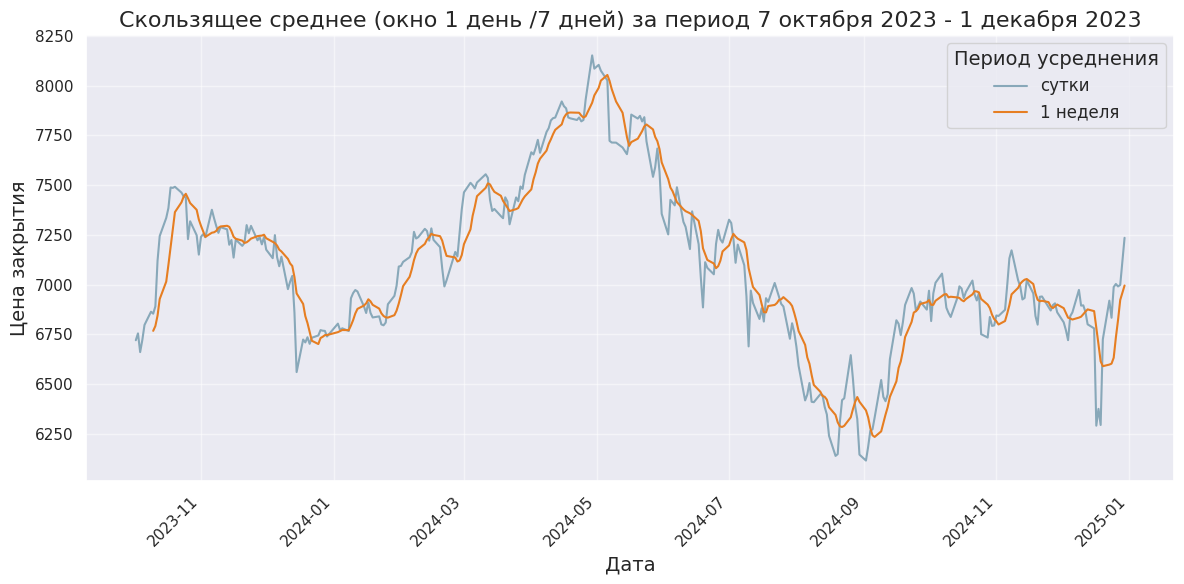

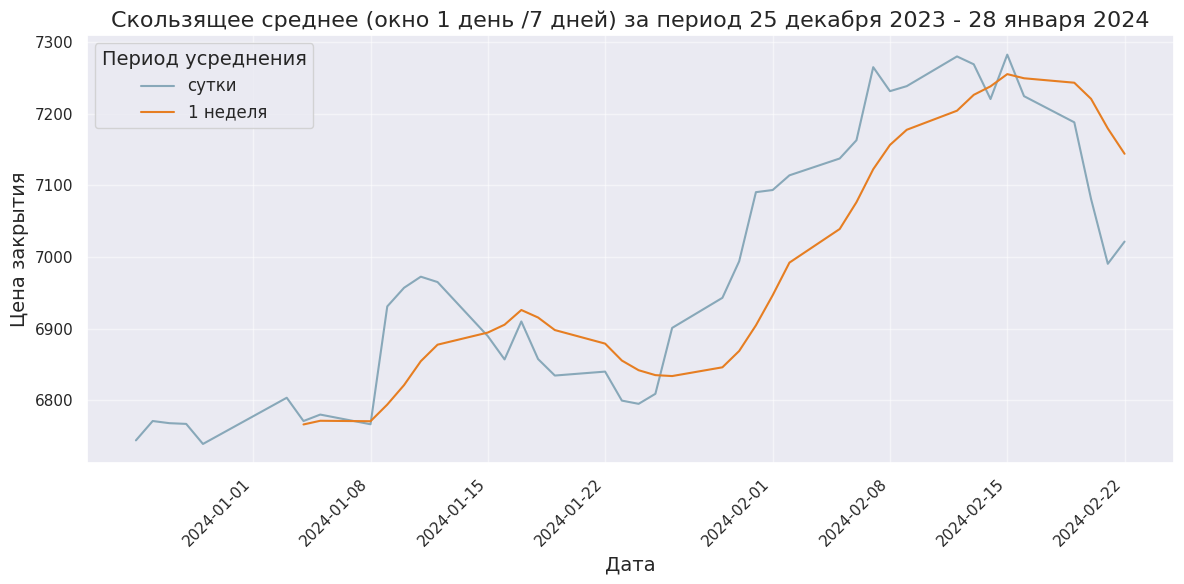

In [ ]:
plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close']['2023-10-01':'2025-01-31'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close']['2023-10-01':'2025-01-31'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящее среднее (окно 1 день /7 дней) за период 7 октября 2023 - 1 декабря 2023', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 6))

# График с разными цветами
df_copy['close']['2023-12-25':'2024-02-25'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['close']['2023-12-25':'2024-02-25'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Скользящее среднее (окно 1 день /7 дней) за период 25 декабря 2023 - 28 января 2024', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Cкользящее окно приняла равное суткам (все равно данные только за сутки) и неделю, чтобы посмотреть на коротком промежутке.
Каких-то определенных тенденций тут не наблюдается ни связанных с днем недели, ни с началом-кончом месяца.

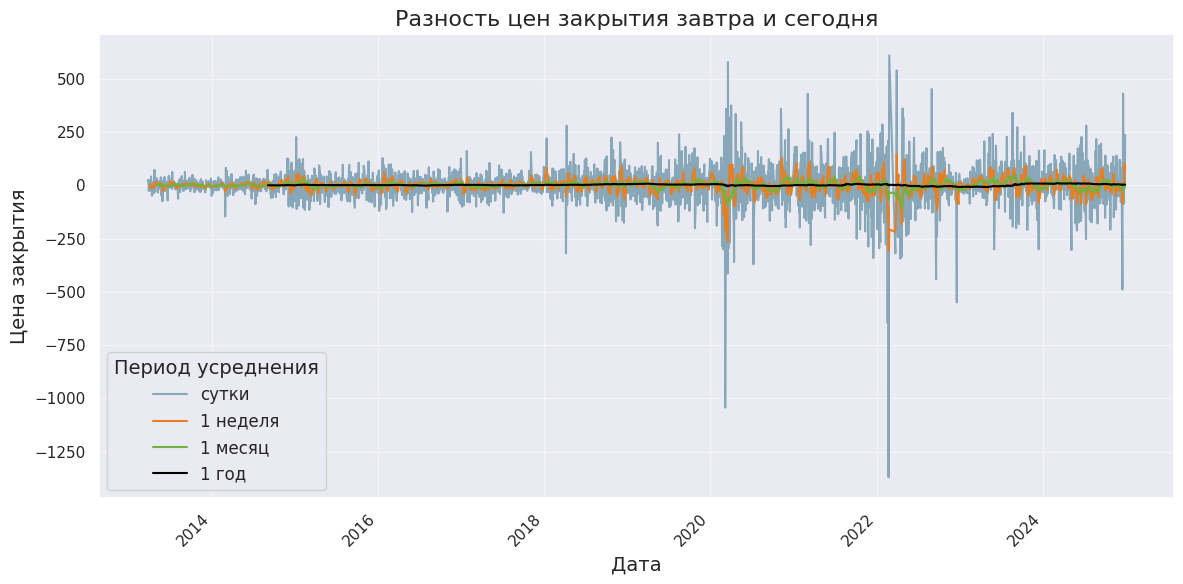

In [ ]:
plt.figure(figsize=(12, 6))

df_copy['price_diff'] = df_copy['close'].diff(-1) * -1  # Разница между следующей ценой и текущей
# График с разными цветами
df_copy['price_diff'].rolling(1).mean().plot(color='#88A8B9', label='сутки')
df_copy['price_diff'].rolling(7).mean().plot(color='#E67E22', label='1 неделя')
df_copy['price_diff'].rolling(29).mean().plot(color='#76B041', label='1 месяц')
df_copy['price_diff'].rolling(365).mean().plot(color='black', label='1 год')

# Добавляем легенду
plt.legend(title='Период усреднения', fontsize=12, title_fontsize=14)

# Настройки графика
plt.xlabel('Дата', fontsize=14)
plt.ylabel('Цена закрытия', fontsize=14)
plt.title('Разность цен закрытия завтра и сегодня', fontsize=16)
plt.grid(alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Тоже не сделать каких-то выводов по сезонности.
На этом работу с временным рядом мы прекращаем и начинаем работать с датасетом как с датасетом под задачу классификации.

## Создание новых признаков из признака "дата"

In [ ]:
# Проверяем тип индекса
if not isinstance(df.index, pd.DatetimeIndex):
    # Если индекс не datetime, преобразуем его
    df.index = pd.to_datetime(df.index)

# Преобразуем индекс в обычный столбец
df['date'] = df.index

# Проверяем формат нового столбца
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    # Если столбец все еще не datetime, преобразуем его
    df['date'] = pd.to_datetime(df['date'])

# Удаляем индекс, если он больше не нужен
df = df.reset_index(drop=True)


In [ ]:
df.head(3)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,target,date
0,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,1.590845e+09,3,NaN,1,2013-03-25
1,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,1.951925e+09,3,1.17,1,2013-03-26
2,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,2.411451e+09,3,1.30,1,2013-03-27


In [ ]:
# Функция для извлечения всех признаков даты
def extract_date_features(date):
    return {
        'day_of_week': date.dayofweek + 1,
        'day_of_month': date.day,
        'month': date.month,
        'year': date.year
    }

# Проверяем и преобразуем столбец date в datetime, если нужно
if not pd.api.types.is_datetime64_any_dtype(df['date']):
    try:
        df['date'] = pd.to_datetime(df['date'])
    except Exception as e:
        print(f"Ошибка преобразования даты: {e}")
        print("Попробуйте указать формат даты, например:")
        # df'date' = pd.to_datetime(df'date', format='%Y-%m-%d')

# Создаем новый DataFrame с признаками
features_df = pd.DataFrame(df['date'].apply(extract_date_features).tolist())

# Добавляем новые столбцы в исходный DataFrame
df = pd.concat([df, features_df], axis=1)

df.drop('date', axis = 1, inplace=True)

In [ ]:
def move_column_to_end(df, column):
    return df[[col for col in df.columns if col != column] + [column]]

# Использование:
df = move_column_to_end(df, 'target')

In [ ]:
df.head(3)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,day_of_month,month,year,target
0,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,1.590845e+09,3,NaN,1,25,3,2013,1
1,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,1.951925e+09,3,1.17,2,26,3,2013,1
2,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,2.411451e+09,3,1.30,3,27,3,2013,1


In [ ]:
def subplots_histplot_hue(df, nrows, title):
    fig, axes = plt.subplots(nrows=nrows, ncols=5, figsize=(13, 13))
    axes = axes.flatten()
    fig.suptitle(title)

    for i, col in enumerate(df):
        sns.histplot(data=df, x=col, hue='target', kde=True, ax=axes[i])
        axes[i].set_title(f'Признак {col}')

    plt.tight_layout()
    plt.show()

## Обучение моделей

### Деление датасета на выборки

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>split_data_res_ind(df, target_column)
def split_data_res_ind(df, target_column):
    """
    Функция для разделения данных на обучающую и тестовую выборки с использованием стратификации.

    Параметры:
    df (pandas.DataFrame): исходный набор данных
    target_column (str): название столбца с целевыми значениями

    Должны быть определены константы
    TEST_SIZE (float): размер тестовой выборки (между 0 и 1)
    RANDOM_STATE (int): начальное значение для генератора случайных чисел
    STRATIFY (str): столбец для стратификации. Равен столбцу target или None.

    Возвращает:
    X_train (pandas.DataFrame): обучающая выборка без столбца с целевыми значениями
    X_test (pandas.DataFrame): тестовая выборка без столбца с целевыми значениями
    y_train (pandas.Series): целевые значения для обучающей выборки
    y_test (pandas.Series): целевые значения для тестовой выборки
    """
    # Удаляем целевой столбец из набора данных
    X = df.drop([target_column], axis=1)
    y = df[target_column]

    # Выполняем разделение данных
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
        stratify=df[target_column]
    )
    X_train.reset_index(drop=True, inplace=True)
    X_test.reset_index(drop=True, inplace=True)
    y_train.reset_index(drop=True, inplace=True)
    y_test.reset_index(drop=True, inplace=True)

    return X_train, X_test, y_train, y_test

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df, 'target')

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_class_distribution_train_test(y_train, y_test, target)
def plot_class_distribution_train_test(y_train, y_test, target):
    """
    Функция для создания графика распределения осложнений в обучающей и тестовой выборках.

    Параметры:
    y_train (pandas.DataFrame): Обучающая выборка данных.
    y_test (pandas.DataFrame): Тестовая выборка данных.
    target (str): Название столбца с данными об осложнениях.
    """

    # Создание DataFrame для обучающей и тестовой выборок
    train = pd.DataFrame(y_train, columns=[target])
    test = pd.DataFrame(y_test, columns=[target])

    # Подготовка графиков
    fig, ax = plt.subplots(figsize=(6, 4))

    # Построение графиков для обучающей и тестовой выборок
    sns.countplot(data=train, y=target, alpha=.5, ax=ax)
    sns.countplot(data=test, y=target, alpha=1, ax=ax)

    # Добавление заголовка к графику
    ax.set_title('Разделение по классам')

    # Отображение графика
    plt.show()

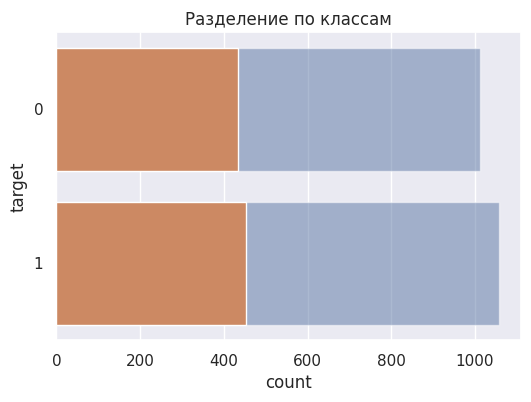

In [ ]:
plot_class_distribution_train_test(y_train, y_test, 'target')

Отлично поделилось по классам, да еще и классы, можно сказать, уравновешены.

### Baseline & Dummy

In [ ]:
# Create CatBoost pools for training and testing
train_pool = Pool(data=X_train, label=y_train,

                  )
test_pool = Pool(data=X_test, label=y_test,
                 #cat_features=categorical_featurs
                 )

# Обучение модели CatBoost
model = CatBoostClassifier()
model.fit(train_pool)

Learning rate set to 0.014053
0:	learn: 0.6929664	total: 58ms	remaining: 57.9s
1:	learn: 0.6926337	total: 63.7ms	remaining: 31.8s
2:	learn: 0.6923304	total: 68.4ms	remaining: 22.7s
3:	learn: 0.6920707	total: 72.8ms	remaining: 18.1s
4:	learn: 0.6917990	total: 78.2ms	remaining: 15.6s
5:	learn: 0.6913845	total: 83.2ms	remaining: 13.8s
6:	learn: 0.6910797	total: 87.7ms	remaining: 12.4s
7:	learn: 0.6909487	total: 91.9ms	remaining: 11.4s
8:	learn: 0.6904442	total: 96.2ms	remaining: 10.6s
9:	learn: 0.6902235	total: 101ms	remaining: 9.95s
10:	learn: 0.6899377	total: 105ms	remaining: 9.43s
11:	learn: 0.6897131	total: 112ms	remaining: 9.19s
12:	learn: 0.6894080	total: 116ms	remaining: 8.81s
13:	learn: 0.6889142	total: 120ms	remaining: 8.47s
14:	learn: 0.6886057	total: 125ms	remaining: 8.18s
15:	learn: 0.6883113	total: 129ms	remaining: 7.92s
16:	learn: 0.6881328	total: 133ms	remaining: 7.69s
17:	learn: 0.6879366	total: 137ms	remaining: 7.48s
18:	learn: 0.6875901	total: 141ms	remaining: 7.29s
19:	

In [ ]:
# Оценка качества модели
predictions = model.predict(test_pool)
f1_baseline = f1_score(y_test, predictions, average='macro')
print("F1-score для Baseline модели:", round(f1_baseline, 3))
roc_auc_baseline = roc_auc_score(y_test, predictions)
print("roc-auc для Baseline модели:", round(roc_auc_baseline, 3))
precision_baseline = precision_score(y_test, predictions)
print("precision для Baseline модели:", round(precision_baseline, 3))
recall_baseline = recall_score(y_test, predictions)
print("recall для Baseline модели:", round(recall_baseline, 3))

F1-score для Baseline модели: 0.502
roc-auc для Baseline модели: 0.502
precision для Baseline модели: 0.514
recall для Baseline модели: 0.52


- Основные метрики качества

**F1-score** модели составляет 0.502, что указывает на относительно невысокое качество классификации. Значение близко к случайному угадыванию (0.5), что говорит о необходимости улучшения модели.

**ROC-AUC** также равен 0.502, что подтверждает предположение о случайном характере предсказаний модели. При таком значении модель не демонстрирует способности эффективно разделять классы.

- Детализация метрик

**Precision** модели составляет 0.514, что означает, что чуть более половины объектов, которые модель предсказала как положительные, действительно являются таковыми. Это говорит о приемлемой точности положительных предсказаний.

**Recall** равен 0.52, что показывает способность модели находить положительные объекты. Модель обнаруживает чуть более половины всех положительных примеров в данных.

- Общий вывод по работе базовой модели

Результаты Baseline модели демонстрируют, что текущая реализация не выходит за рамки случайного угадывания. Основные метрики качества находятся на уровне 0.5, что является минимальным приемлемым значением.

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_confusion_matrix(y_test, predictions)
def plot_confusion_matrix(y_test, predictions, figsize=(4, 4)):
    """
    Функция для построения матрицы ошибок.

    Параметры:
    y_test (array): массив с истинными значениями.
    predictions (array): массив с предсказанными значениями.
    figsize (tuple, optional): размер фигуры.
    """

    # Создание графиков
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(figsize[0]*2, figsize[1]))

    # Добавление заголовка
    plt.suptitle('Confusion Matrix', fontsize=16)

    # Вычисление и построение матрицы ошибок
    cm = confusion_matrix(y_test, predictions)

    # Абсолютные значения
    hmap1 = sns.heatmap(cm, annot=True, cbar=False, cmap='GnBu', ax=ax1,
                       fmt='.0f', cbar_kws={'label': 'Counts'})
    ax1.set_title('Absolute Values')

    # Процентные значения
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    hmap2 = sns.heatmap(cm_percent, annot=True, cbar=False, cmap='GnBu', ax=ax2,
                       fmt='.2f', cbar_kws={'label': 'Percentages'})
    ax2.set_title('Percentage Values')

    # Добавление меток
    plt.ylabel('Actual')
    plt.xlabel('Predicted')

    # Настройка расположения элементов графика
    plt.tight_layout()

    # Сохранение графика в файл
    plt.savefig('cm.png', dpi=300)

    # Отображение графика
    plt.show()

    # Сброс стилей Seaborn к исходным
    sns.reset_orig()

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>plot_feature_importance(model, X_test)
def plot_feature_importance(model, X_test):
    """
    Функция для построения графика важности признаков модели.

    Параметры:
    model (объект модели): обученная модель, из которой извлекаются значения важности признаков.
    X_test_base (pandas.DataFrame): DataFrame с признаками для тестирования.
    """

    # Определение данных для графика
    plot_data = {
        'features': X_test.columns,
        'feature_importances': model.feature_importances_,
    }

    # Преобразование в DataFrame
    plot_data = pd.DataFrame(plot_data)

    # Фильтрация признаков с положительными значениями важности
    plot_data = plot_data[plot_data['feature_importances'] > 0]

    # Сортировка по убыванию важности признаков
    plot_data.sort_values(by='feature_importances', ascending=False, inplace=True)

    # Настройка и построение графика
    plt.figure(figsize=(10, 5))
    sns.barplot(x='feature_importances', y='features', data=plot_data)

    # Добавление заголовка
    plt.title('Важность признаков модели \n', fontsize=14, fontweight="bold")

    # Отображение графика
    plt.show()

    # Сброс стилей Seaborn к исходным
    sns.reset_orig()

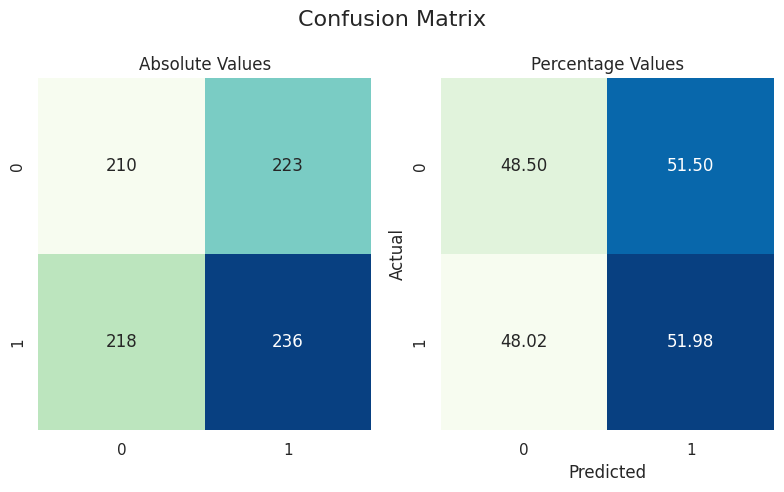

In [ ]:
plot_confusion_matrix(y_test, predictions, figsize=(4, 5))

Матрица ошибок нам также подтверждает вывод по метрикам, что модель не выходит за рамки случайного угадывания.

Посмотрим как работает простая Dummy-модель.

In [ ]:
# Инициализация и обучение DummyClassifier
dummy_mean = DummyClassifier()
dummy_mean.fit(X_train, y_train)

# Прогнозирование на тестовых данных и вычисление F1-score
dummy_prediction = dummy_mean.predict(X_test)


f1_dummy = f1_score(y_test, dummy_prediction, average='macro')
print("F1-score для Dummy модели:", round(f1_dummy, 3))
roc_auc_dummy = roc_auc_score(y_test, dummy_prediction)
print("roc-auc для Dummy модели:", round(roc_auc_dummy, 3))
precision_dummy = precision_score(y_test, dummy_prediction)
print("precision для Dummy модели:", round(precision_dummy, 3))
recall_dummy = recall_score(y_test, dummy_prediction)
print("recall для Dummy модели:", round(recall_dummy, 3))

F1-score для Dummy модели: 0.339
roc-auc для Dummy модели: 0.5
precision для Dummy модели: 0.512
recall для Dummy модели: 1.0


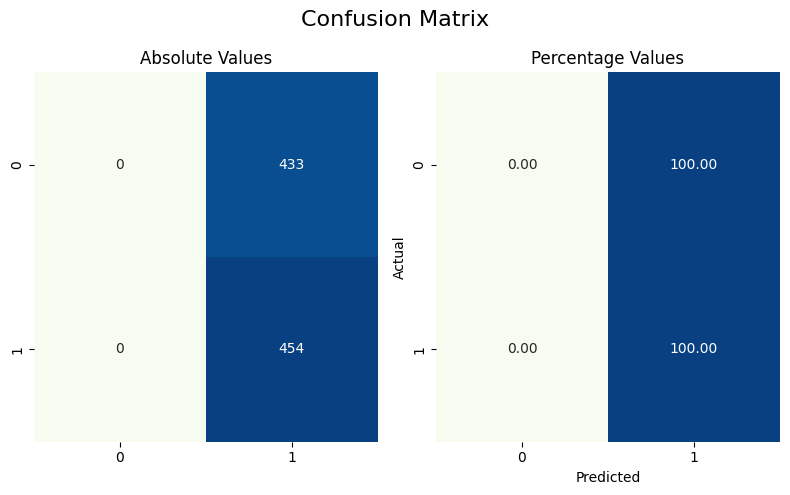

In [ ]:
plot_confusion_matrix(y_test, dummy_prediction, figsize=(4, 5))

Базовая модель по метрикам сравнима с простым Dummy-классификатором, который записывает все в класс, которого больше.
При этом precision даже выше у Dummy, хотя мы видим, что она ничего не угадывает.

Ну, есть, к чему стремиться.

### Функции для обучения моделей.

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_models
def find_best_models(X_train, y_train, X_test, y_test, models_params):
    '''
    Функция выполняет поиск лучшей модели из словаря с использованием скейлера,
    скоринг по f1_macro, добавлены метрики roc_auc, precision и recall
    '''
    best_models = []

    for model_name, (model, params) in models_params.items():
        # Создаем пайплайн со скейлером
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])

        gs_model = GridSearchCV(
            pipeline,
            params,
            cv=5,
            scoring='precision_macro',
            n_jobs=-1
        )
        gs_model.fit(X_train, y_train)

        best_score = gs_model.best_score_
        best_estimator = gs_model.best_estimator_
        best_params = gs_model.best_params_

        # Получаем предсказания для метрик на трейне
        y_pred_train = best_estimator.predict(X_train)
        roc_auc_train = roc_auc_score(y_train, y_pred_train, average='macro')
        f1_train = f1_score(y_train, y_pred_train, average='macro')
        recall_train = recall_score(y_train, y_pred_train, average='macro')

        # Делаем предсказание на тесте
        y_pred = best_estimator.predict(X_test)
        precision_test = precision_score(y_test, y_pred, average='macro')
        roc_auc = roc_auc_score(y_test, y_pred, average='macro')
        f1_test = f1_score(y_test, y_pred, average='macro')
        recall_test = recall_score(y_test, y_pred, average='macro')

        # Сохранение результатов
        best_models.append({
            'model_name': f'{model_name}',
            'best_estimator': best_estimator,
            'best_params': best_params,
            'best_score_cv': best_score,
            'precision_test': precision_test,
            'roc_auc_train': roc_auc_train,
            'roc_auc': roc_auc,
            'f1_train': f1_train,
            'f1_test': f1_test,
            'recall_train': recall_train,
            'recall_test': recall_test
        })

        print(f'{model_name}:')
        print(f'Метрика Precision на кросс-валидации: {best_score:.3f}')
        print(f'Метрика Precision на тесте: {precision_test:.3f}')
        print(f'Метрика ROC AUC на трейне: {roc_auc_train:.3f}')
        print(f'Метрика ROC AUC на тесте: {roc_auc:.3f}')
        print(f'Метрика F1 Macro на трейне: {f1_train:.3f}')
        print(f'Метрика F1 Macro на тесте: {f1_test:.3f}')
        print(f'Метрика Recall на трейне: {recall_train:.3f}')
        print(f'Метрика Recall на тесте: {recall_test:.3f}')
        print("Лучшая модель:", best_estimator)
        print('-'*40)

    return best_models

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>create_results_dataframe(best_models_list)
def create_results_dataframe(best_models_list):
    global_results_data = []
    for model_info in best_models_list:
        results_data.append({
            'Model': model_info['model_name'],
            'Best Model': model_info['best_estimator'],
            'Best params': model_info['best_params'],
            'PRECISION CV': f"{model_info['best_score_cv']:.3f}",
            'PRECISION TEST': f"{model_info['precision_test']:.3f}",
            'ROC AUC TRAIN': f"{model_info['roc_auc_train']:.3f}",
            'ROC AUC TEST': f"{model_info['roc_auc']:.3f}",
            'F1 TRAIN' : f"{model_info['f1_train']:.3f}",
            'F1 TEST' : f"{model_info['f1_test']:.3f}",
            'RECALL TRAIN' : f"{model_info['recall_train']:.3f}",
            'RECALL TEST' : f"{model_info['recall_test']:.3f}",

        })
    return pd.DataFrame(results_data)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>find_best_model(results_data)
# Объявляем глобальную переменную
best_model = None

def find_best_model(results_data):
    """
    Функция для поиска лучшей модели по метрике PRECISION CV

    Параметры:
    results_data (list/dict): данные с результатами моделей

    Возвращает:
    best_model: модель с максимальным значением PRECISION CV
    """
    global best_model  # Указываем, что используем глобальную переменную

    try:
        # Создаем DataFrame из входных данных
        result_df = pd.DataFrame(results_data)

        metrics_columns = [
            'PRECISION CV', 'PRECISION TEST', 'ROC AUC TRAIN', 'ROC AUC TEST',
            'F1 TRAIN', 'F1 TEST', 'RECALL TRAIN', 'RECALL TEST'
            ]
        # Преобразуем все столбцы в float
        for column in metrics_columns:
          result_df[column] = pd.to_numeric(result_df[column], errors='coerce')

        # Находим индекс строки с максимальной метрикой
        best_model_index = np.argmax(result_df['PRECISION CV'] + result_df['ROC AUC TRAIN'])

        # Получаем лучшую модель
        best_model = result_df.loc[best_model_index, 'Best Model']

        # Выводим результат
        print(f"Лучшая модель: {best_model}")
        return best_model

    except Exception as e:
        print(f"Ошибка при поиске лучшей модели: {e}")
        return None

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>save_results(best_model, filename='best_model.pkl')
# Функция для сохранения результатов
def save_results(best_model, filename='best_model.pkl'):
    joblib.dump(best_model, filename)
    print(f"Результаты сохранены в файл: {filename}")
# Функция для загрузки результатов
def load_results(filename='best_models.pkl'):
    return joblib.load(filename)

# Пример использования:
# loaded_models = load_results()
# analyze_results(loaded_models)

In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>dummy_precision_score(X_train, y_train, X_test, y_test)
def dummy_precision_score(X_train, y_train, X_test, y_test):
    """
    Функция для вычисления precision-score для DummyClassifier.

    Параметры:
    X_train (pandas.DataFrame): Обучающие данные.
    y_train (pandas.Series): Обучающие метки.
    X_test (pandas.DataFrame): Тестовые данные.
    y_test (pandas.Series): Тестовые метки.

    Возвращает:
    float: precision-score для DummyClassifier.
    """

    # Инициализация и обучение DummyClassifier
    dummy_mean = DummyClassifier()
    dummy_mean.fit(X_train, y_train)

    # Прогнозирование на тестовых данных и вычисление F1-score
    dummy_prediction = dummy_mean.predict(X_test)
    precision_dummy = precision_score(y_test, dummy_prediction, average='macro')

    # Округление и вывод результата
    precision_dummy = round(abs(precision_dummy), 3)
    print(f'F1 Macro DummyClassifier = {precision_dummy}')

    return precision_dummy


In [ ]:
# @title <font color='#4189ab'>def <font color='#d98007'>get_matrices(df, X_test, y_test, start_index=0, end_index=None)
def get_matrices(df, X_test, y_test, start_index=0, end_index=None):
    confusion_matrices = []

    # Проверяем индексы
    if end_index is None:
        end_index = len(df)

    # Проверяем корректность индексов
    if start_index < 0:
        start_index = 0
    if end_index > len(df):
        end_index = len(df)

    # Выбираем нужный диапазон строк
    filtered_df = df.iloc[start_index:end_index]

    for index, row in filtered_df.iterrows():
        try:
            # Получаем пайплайн
            pipeline = row['Best Model']
            model_name = row['Model']

            # Делаем предсказания
            y_pred = pipeline.predict(X_test)

            # Создаем матрицу ошибок
            try:
                confusion_matrix = plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))
                confusion_matrices.append(confusion_matrix)

                print(f"\033[1m Confusion matrix created for {model_name} \033[0m")
                print("-" * 50)
            except Exception as e:
                print(f"Error creating confusion matrix for {model_name}: {e}")
                confusion_matrices.append(None)

        except Exception as e:
            print(f"Error with pipeline {index}: {e}")
            predictions.append(None)
            confusion_matrices.append(None)

    return predictions, confusion_matrices

## Feature Engineering

In [ ]:
df.head(1)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,marketprice3tradesvalue,tradingsession,trendclspr,day_of_week,day_of_month,month,year,target
0,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,1.590845e+09,3,NaN,1,25,3,2013,1


Для начала создадим простые признаки из основных признаков цен.
Также не забудем о признаке конца квартала, он может оказаться значимым

In [ ]:
df['close-open']  = df['close'] - df['open'] # столбец разницы цен закрытия и открытия.
df['high-low']  = df['high'] - df['low']
# df['tendency'] = (df['close-open'] > 0).astype(int) # если нет столбца trendclspr - но он есть
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)

Поскольку решение о покупке будем принимать утром в момент открытия биржи, добавим разницу между первой сделкой утра и последней вчерашнего вечера.

In [ ]:
df['open_tomorrow-close_today'] = df['open'].shift(-1) - df['close']

Добавим технические индикаторы

In [ ]:
# Технические индикаторы
def calculate_rsi(series, period=14):
    delta = series.diff().dropna()
    up, down = delta.copy(), delta.copy()
    up[up < 0] = 0
    down[down > 0] = 0
    gain = up.ewm(com=period-1, min_periods=period).mean()
    loss = down.abs().ewm(com=period-1, min_periods=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calculate_macd(series, fastperiod=12, slowperiod=26, signalperiod=9):
    exp1 = series.ewm(span=fastperiod, adjust=False).mean()
    exp2 = series.ewm(span=slowperiod, adjust=False).mean()
    macd = exp1 - exp2
    signal = macd.ewm(span=signalperiod, adjust=False).mean()
    return macd, signal

In [ ]:
# RSI (Relative Strength Index) - индекс относительной силы
# Показывает силу текущего тренда и возможность его разворота
# Значения от 0 до 100, обычно используется для определения перекупленности/перепроданности
df['RSI'] = calculate_rsi(df['close'])

# MACD (Moving Average Convergence Divergence) - схождение/расхождение скользящих средних
# Помогает определить направление тренда и возможные точки входа/выхода
# Состоит из двух линий: MACD и сигнальной линии
df['MACD'], df['MACD_Signal'] = calculate_macd(df['close'])

# Скользящие средние
# SMA_5 - простая скользящая средняя за 5 периодов
# Используется для определения краткосрочного тренда
df['SMA_5'] = df['close'].rolling(window=5).mean()

# EMA_20 - экспоненциальная скользящая средняя за 20 периодов
# Более чувствительна к последним данным, чем SMA
# Помогает определить среднесрочный тренд
df['EMA_20'] = df['close'].ewm(span=20).mean()

# Показатели изменения цен
# Daily_Return - дневной процентный прирост/снижение цены
# Показывает относительное изменение цены закрытия
df['Daily_Return'] = df['close'].pct_change()

# Log_Return - логарифмическая доходность
# Используется для более точной оценки сложных процентов
# Особенно полезен при работе с долгосрочными временными рядами
df['Log_Return'] = np.log(df['close'] / df['close'].shift(1))

# Временные паттерны
# Is_Weekend - индикатор выходных дней
# Принимает значение 1 если день суббота (5) или воскресенье (6), иначе 0
df['Is_Weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Is_Month_End - индикатор конца месяца
# Принимает значение True если день является последним в месяце
df['Is_Month_End'] = df['day_of_month'] == df['day_of_month'].max()

# Объемные показатели
# Volume_MA - скользящая средняя объема торгов
# Помогает определить изменения в активности трейдеров
# Используется для подтверждения силы тренда
df['Volume_MA'] = df['volume'].rolling(window=10).mean()

In [ ]:
# Заменяем оставшиеся NaN на среднее значение или предыдущее значение
df['RSI'] = df['RSI'].fillna(method='ffill')  # заполняем предыдущими значениями

In [ ]:
# Перенос таргета в конец:
df = move_column_to_end(df, 'target')

In [ ]:
df.head(5)

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,open_tomorrow-close_today,RSI,MACD,MACD_Signal,SMA_5,EMA_20,Daily_Return,Log_Return,Is_Weekend,Is_Month_End,Volume_MA,target
0,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,...,-1.5,NaN,0.000000,0.000000,NaN,1922.000000,NaN,NaN,0,False,NaN,1
1,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,...,-2.2,NaN,1.794872,0.358974,NaN,1933.812500,0.011707,0.011639,0,False,NaN,1
2,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,...,-10.9,NaN,5.190912,1.325362,NaN,1946.990175,0.012960,0.012876,0,False,NaN,1
3,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1.536170e+09,...,5.9,NaN,9.667116,2.993713,NaN,1960.330237,0.011931,0.011860,0,False,NaN,1
4,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,5.624588e+08,...,-10.0,NaN,13.877622,5.170495,1966.56,1970.748446,0.005117,0.005104,1,False,NaN,0


Теперь добавим признаки отстающих значений и скользящего среднего

In [ ]:
# создаем функцию генерации новых признаков
def make_features(data, max_lag, rolling_mean_size):

    # численные признаки
    data['units'] = data.volume/data.close

    # отстающие значения
    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['close'].shift(lag)

    # скользящее среднее без учета текущего значения
    data['rolling_mean'] =\
    data['close'].shift().rolling(rolling_mean_size).mean()

# задаем параметры
make_features(df, 15, 15)

# проверяем
display(df.head())
df.info()

,numtrades,value,open,low,high,legalcloseprice,waprice,close,volume,marketprice2,marketprice3,mp2valtrd,...,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean
0,301,62920708.6,1951.7,1920.7,1963.7,1922.6,1939.5,1922.0,32441,1939.8,1939.8,1.590845e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24,7035671.0,1920.5,1919.8,1944.5,1938.7,1926.0,1944.5,3653,1930.0,1930.0,1.951925e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19,3738545.3,1942.3,1930.0,1971.2,1970.5,1943.1,1969.7,1924,1947.9,1947.9,2.411451e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,33,6719742.2,1958.8,1958.5,1994.6,1994.6,1977.6,1993.2,3398,1974.1,1974.1,1.536170e+09,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,25,3814674.4,1999.1,1996.2,2003.7,2003.1,1999.3,2003.4,1908,1998.3,1998.3,5.624588e+08,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 51 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   numtrades                  2956 non-null   int64  
 1   value                      2956 non-null   float64
 2   open                       2956 non-null   float64
 3   low                        2956 non-null   float64
 4   high                       2956 non-null   float64
 5   legalcloseprice            2956 non-null   float64
 6   waprice                    2956 non-null   float64
 7   close                      2956 non-null   float64
 8   volume                     2956 non-null   int64  
 9   marketprice2               2956 non-null   float64
 10  marketprice3               2956 non-null   float64
 11  mp2valtrd                  2956 non-null   float64
 12  marketprice3tradesvalue    2956 non-null   float64
 13  tradingsession             2956 non-null   int64

In [ ]:
# Переносим таргет в конец:
df = move_column_to_end(df, 'target')

In [ ]:
df = df.dropna()

interval columns not set, guessing: ['numtrades', 'value', 'open', 'low', 'high', 'legalcloseprice', 'waprice', 'close', 'volume', 'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue', 'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month', 'month', 'year', 'close-open', 'high-low', 'is_quarter_end', 'open_tomorrow-close_today', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5', 'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA', 'units', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'rolling_mean', 'target']


<Axes: >

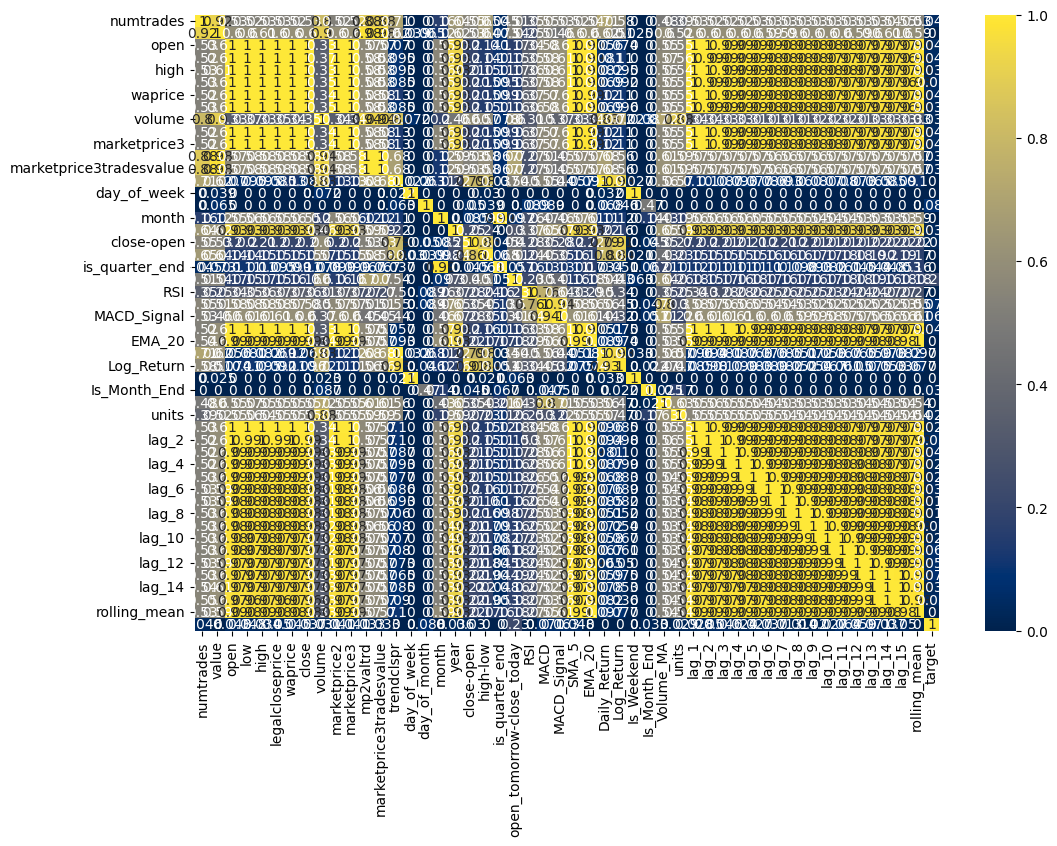

In [ ]:
#interval_cols = ['day_of_week', 'day_of_month', 'month', 'year', 'is_quarter_end']
plt.figure(figsize = (12,8))
sns.heatmap(df.phik_matrix(
    #interval_cols=interval_cols
    ), annot=True, cmap='cividis')

In [ ]:
Удалим высокоскоррелированные признаки цены, поскольку мы уже создали новые на их основе и таким образом не потеряем в данных.

In [ ]:
df1 = df.drop(['open',	'high',	'low',	'close'], axis = 1)

interval columns not set, guessing: ['numtrades', 'value', 'legalcloseprice', 'waprice', 'volume', 'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue', 'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month', 'month', 'year', 'close-open', 'high-low', 'is_quarter_end', 'open_tomorrow-close_today', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5', 'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA', 'units', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'rolling_mean', 'target']


<Axes: >

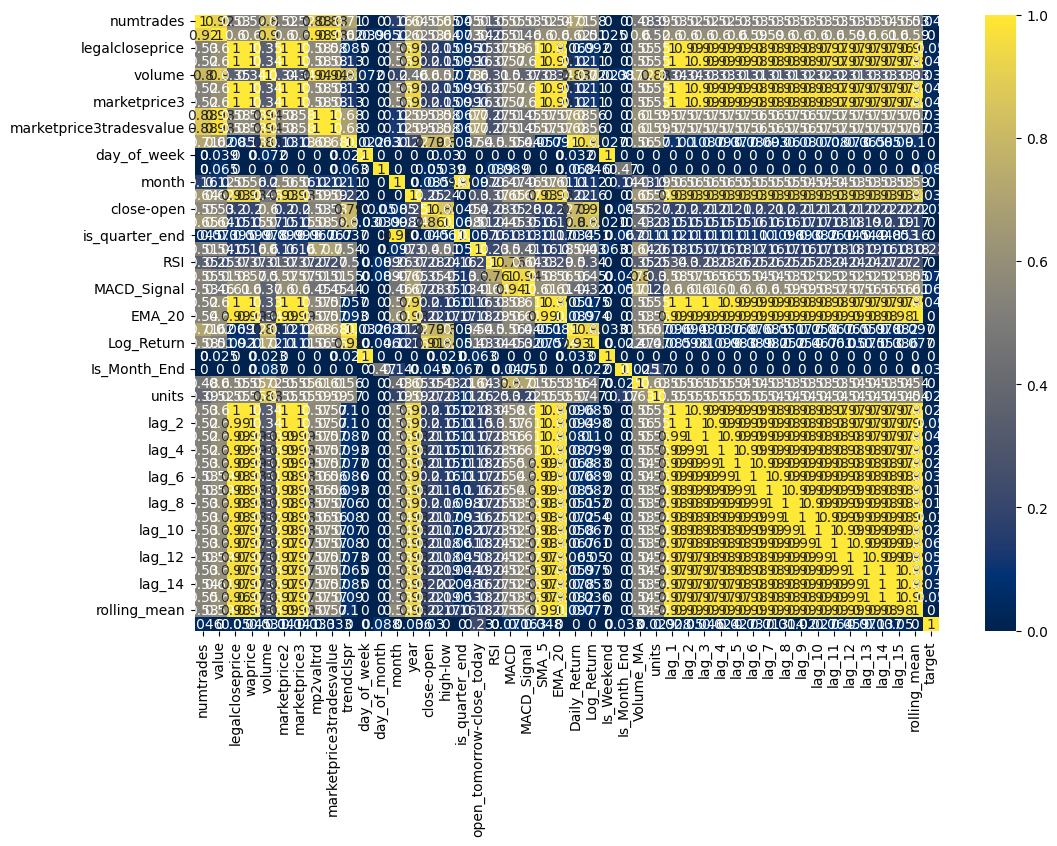

In [ ]:
plt.figure(figsize = (12,8))
sns.heatmap(df1.phik_matrix(
    #interval_cols=interval_cols
    ), annot=True, cmap='cividis')

Для первой попытки оставим все полученные признаки, невзирая на взаимные их корреляции. Заметим, что отстающие значения у нас высокоскорерлированы, но это нормально.

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df1, 'target')

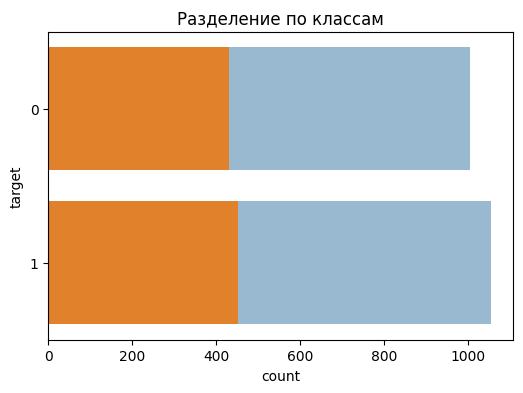

In [ ]:
plot_class_distribution_train_test(y_train, y_test, 'target')

## Обучение моделей

### Обучение на всех признаках

In [ ]:
results_data = []

In [ ]:
# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
    }
# Параметры для случайного леса
rf_params = {
    #'model__max_features': range(1, 20, 2),
    'model__max_depth': range(1, 15, 2),
    'model__min_samples_leaf': range(2,12,2),
    'model__min_samples_split': range(2,8,2),
    }
# Параметры для LGBM
lgbm_params = {
    'model___estimators':  range(1, 20, 2),
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
    }


# Словарь моделей и их параметров
models_params = {
    'DecisionTreeClassifier' : (DecisionTreeClassifier(random_state=RANDOM_STATE), dt_params),
    'RandomForestClassifier' : (RandomForestClassifier(random_state=RANDOM_STATE), rf_params),
    'LGBMClassifier' : (LGBMClassifier(random_state=RANDOM_STATE), lgbm_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)


DecisionTreeClassifier:
Метрика Precision на кросс-валидации: 0.583
Метрика Precision на тесте: 0.587
Метрика ROC AUC на трейне: 0.585
Метрика ROC AUC на тесте: 0.569
Метрика F1 Macro на трейне: 0.561
Метрика F1 Macro на тесте: 0.542
Метрика Recall на трейне: 0.585
Метрика Recall на тесте: 0.569
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(max_depth=1, max_features=25,
                                        min_samples_leaf=2,
                                        random_state=654321))])
----------------------------------------
RandomForestClassifier:
Метрика Precision на кросс-валидации: 0.572
Метрика Precision на тесте: 0.587
Метрика ROC AUC на трейне: 0.724
Метрика ROC AUC на тесте: 0.586
Метрика F1 Macro на трейне: 0.724
Метрика F1 Macro на тесте: 0.585
Метрика Recall на трейне: 0.724
Метрика Recall на тесте: 0.586
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model

In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
0,DecisionTreeClassifier,"(StandardScaler(), DecisionTreeClassifier(max_...","{'model__max_depth': 1, 'model__max_features':...",0.583,0.587,0.585,0.569,0.561,0.542,0.585,0.569
1,RandomForestClassifier,"(StandardScaler(), (DecisionTreeClassifier(max...","{'model__max_depth': 5, 'model__min_samples_le...",0.572,0.587,0.724,0.586,0.724,0.585,0.724,0.586
2,LGBMClassifier,"(StandardScaler(), LGBMClassifier(_estimators=...","{'model___estimators': 1, 'model__learning_rat...",0.569,0.592,0.816,0.592,0.816,0.592,0.816,0.592


In [ ]:
# Параметры для Catboost

catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    #'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass']
    }
'''
catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass'],
    'model__l2_leaf_reg': [3, 5, 7],  # регуляризация
    'model__iterations': [500, 1000],  # количество итераций
    'model__bootstrap_type': ['Bayesian'],  # тип бутстрапа
    'model__od_wait': [50],  # early stopping
    'model__border_count': [32, 64],  # количество границ для бинаризации
    'model__one_hot_max_size': [5],  # максимальный размер one-hot encoding
}
'''
# Словарь моделей и их параметров
models_params = {
    'CatBoostClassifier' : (CatBoostClassifier(random_state=RANDOM_STATE,
                               iterations=1000,
                               verbose=False
                               ), catb_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostClassifier:
Метрика Precision на кросс-валидации: 0.574
Метрика Precision на тесте: 0.568
Метрика ROC AUC на трейне: 0.972
Метрика ROC AUC на тесте: 0.567
Метрика F1 Macro на трейне: 0.972
Метрика F1 Macro на тесте: 0.567
Метрика Recall на трейне: 0.972
Метрика Recall на тесте: 0.567
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e655d690>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
0,DecisionTreeClassifier,"(StandardScaler(), DecisionTreeClassifier(max_...","{'model__max_depth': 1, 'model__max_features':...",0.583,0.587,0.585,0.569,0.561,0.542,0.585,0.569
1,RandomForestClassifier,"(StandardScaler(), (DecisionTreeClassifier(max...","{'model__max_depth': 5, 'model__min_samples_le...",0.572,0.587,0.724,0.586,0.724,0.585,0.724,0.586
2,LGBMClassifier,"(StandardScaler(), LGBMClassifier(_estimators=...","{'model___estimators': 1, 'model__learning_rat...",0.569,0.592,0.816,0.592,0.816,0.592,0.816,0.592
3,CatBoostClassifier,"(StandardScaler(), <catboost.core.CatBoostClas...","{'model__depth': 3, 'model__learning_rate': 0.1}",0.574,0.568,0.972,0.567,0.972,0.567,0.972,0.567


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e655d690>)])


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e655d690>)])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model.pkl')

Результаты сохранены в файл: best_model.pkl


In [ ]:
best_model

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e655d690>)])

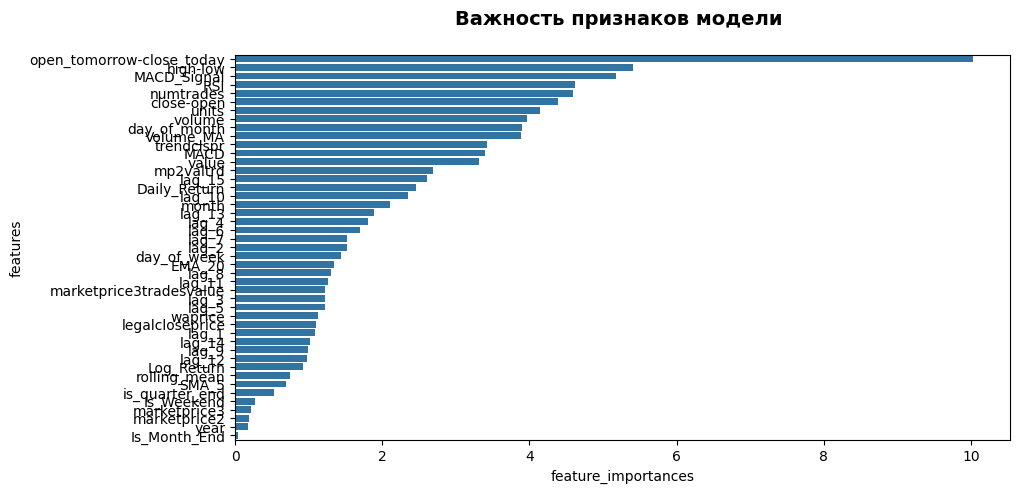

In [ ]:
# Получаем доступ к модели внутри Pipeline
best_model_model = best_model.named_steps['model']

plot_feature_importance(best_model_model, X_test)

Лучшую модель будем выбирать по сумме метрик 'PRECISION CV' и 'ROC AUC TRAIN'. Это, как показала практика, в большинстве случаев даст нам модель с лучшей матрицей ошибок.

In [ ]:
result_df = pd.DataFrame(results_data)

metrics_columns = [
    'PRECISION CV',
    'PRECISION TEST',
    'ROC AUC TRAIN',
    'ROC AUC TEST',
    'F1 TRAIN',
    'F1 TEST',
    'RECALL TRAIN',
    'RECALL TEST'
]
# Преобразуем все столбцы в float
for column in metrics_columns:
    result_df[column] = pd.to_numeric(result_df[column], errors='coerce')

# Находим индекс строки с максимальной метрикой на тесте
best_model_index = np.argmax(result_df['PRECISION CV'] + result_df['ROC AUC TRAIN'])

# Выводим строку с максимальным значением F1 TEST
display(result_df.loc[[best_model_index]])

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
3,CatBoostClassifier,"(StandardScaler(), <catboost.core.CatBoostClas...","{'model__depth': 3, 'model__learning_rate': 0.1}",0.574,0.568,0.972,0.567,0.972,0.567,0.972,0.567


In [ ]:
y_pred = best_model.predict(X_test)

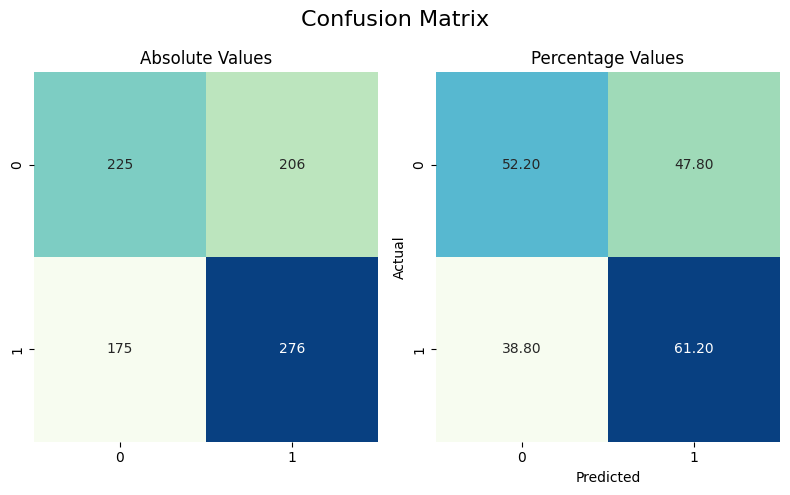

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))

In [ ]:
def get_matrices(df, X_test, y_test, start_index=0, end_index=None):
    confusion_matrices = []

    # Проверяем индексы
    if end_index is None:
        end_index = len(df)

    # Проверяем корректность индексов
    if start_index < 0:
        start_index = 0
    if end_index > len(df):
        end_index = len(df)

    # Выбираем нужный диапазон строк
    filtered_df = df.iloc[start_index:end_index]

    for index, row in filtered_df.iterrows():
        try:
            # Получаем пайплайн
            pipeline = row['Best Model']
            model_name = row['Model']

            # Делаем предсказания
            y_pred = pipeline.predict(X_test)

            # Создаем матрицу ошибок
            try:
                confusion_matrix = plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))
                confusion_matrices.append(confusion_matrix)

                print(f"\033[1m Confusion matrix created for {model_name} \033[0m")
                print("-" * 50)
            except Exception as e:
                print(f"Error creating confusion matrix for {model_name}: {e}")
                confusion_matrices.append(None)

        except Exception as e:
            print(f"Error with pipeline {index}: {e}")
            predictions.append(None)
            confusion_matrices.append(None)

    return predictions, confusion_matrices

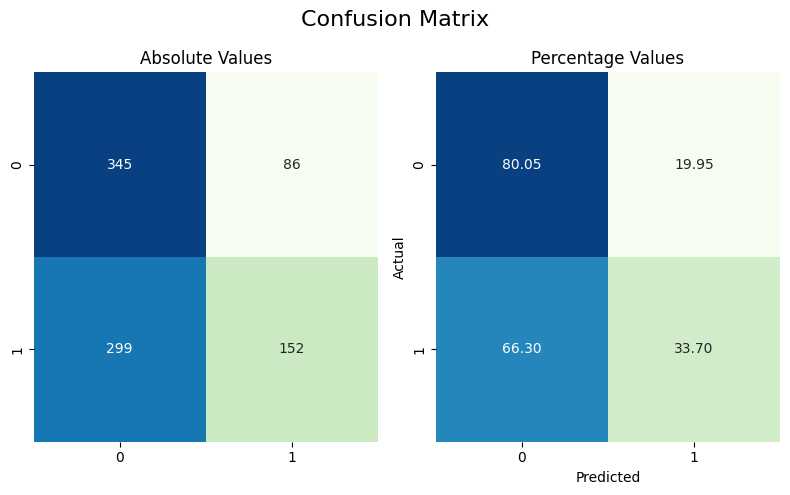

 Confusion matrix created for DecisionTreeClassifier 
--------------------------------------------------


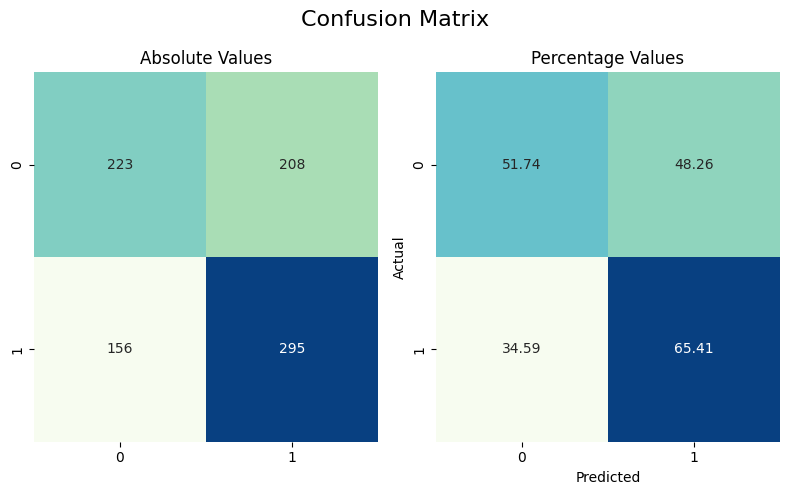

 Confusion matrix created for RandomForestClassifier 
--------------------------------------------------


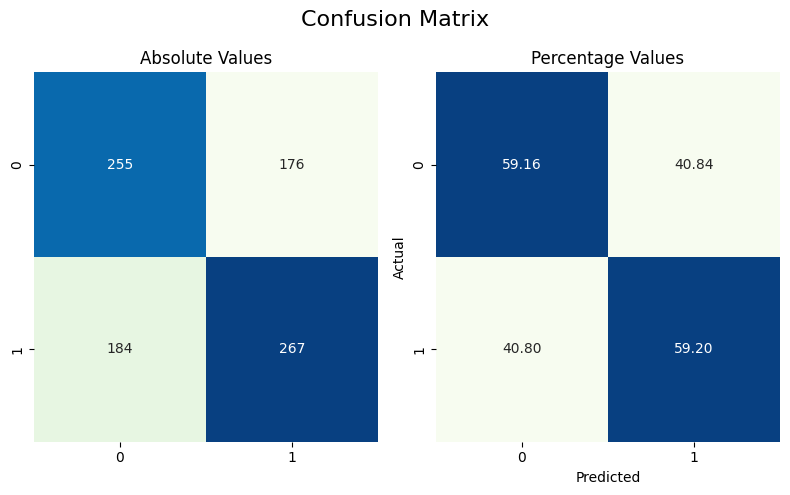

 Confusion matrix created for LGBMClassifier 
--------------------------------------------------


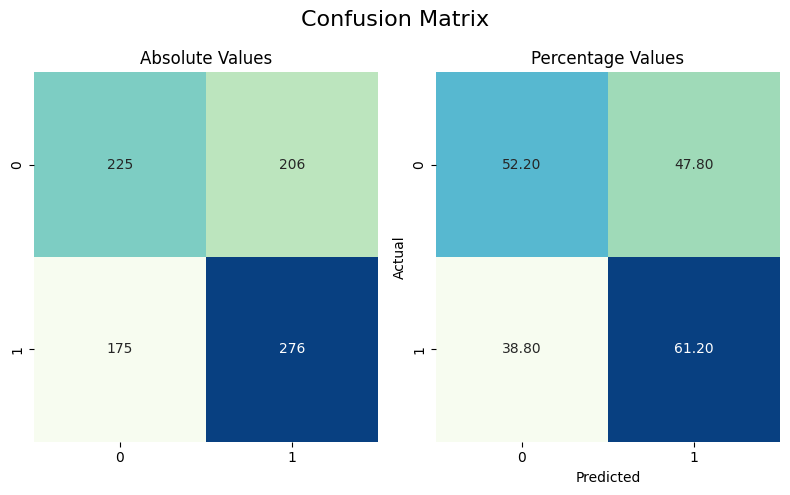

 Confusion matrix created for CatBoostClassifier 
--------------------------------------------------


In [ ]:
matrices = get_matrices(result_df, X_test, y_test, 0, 5)

Возможно. имеет смысл рассмотреть модель LGBMClassifier, которая дает более уравновешенную матрицу и мы могли бы использовать ее на покупку и продажу.

Однако, отметим тот момент, что все модели не дотягивают в метриках даже до 0,6, таким образом, они все имеют низкую предсказательную способность и рисковать играя на бирже,пользуясь ими, не рекомендуется.

### Уберем высокоскоррелированные ячейки

In [ ]:
columns = ['open', 'low', 'high', 'close', 'numtrades', 'value', 'legalcloseprice', 'waprice',
           'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue',
           'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month',
           'month', 'year', 'high-low', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5',
           'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA',
           'units' ]
df2 = df.drop(columns, axis=1)

In [ ]:
df2 = move_column_to_end(df2, 'target')

interval columns not set, guessing: ['volume', 'close-open', 'is_quarter_end', 'open_tomorrow-close_today', 'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7', 'lag_8', 'lag_9', 'lag_10', 'lag_11', 'lag_12', 'lag_13', 'lag_14', 'lag_15', 'rolling_mean', 'target']


<Axes: >

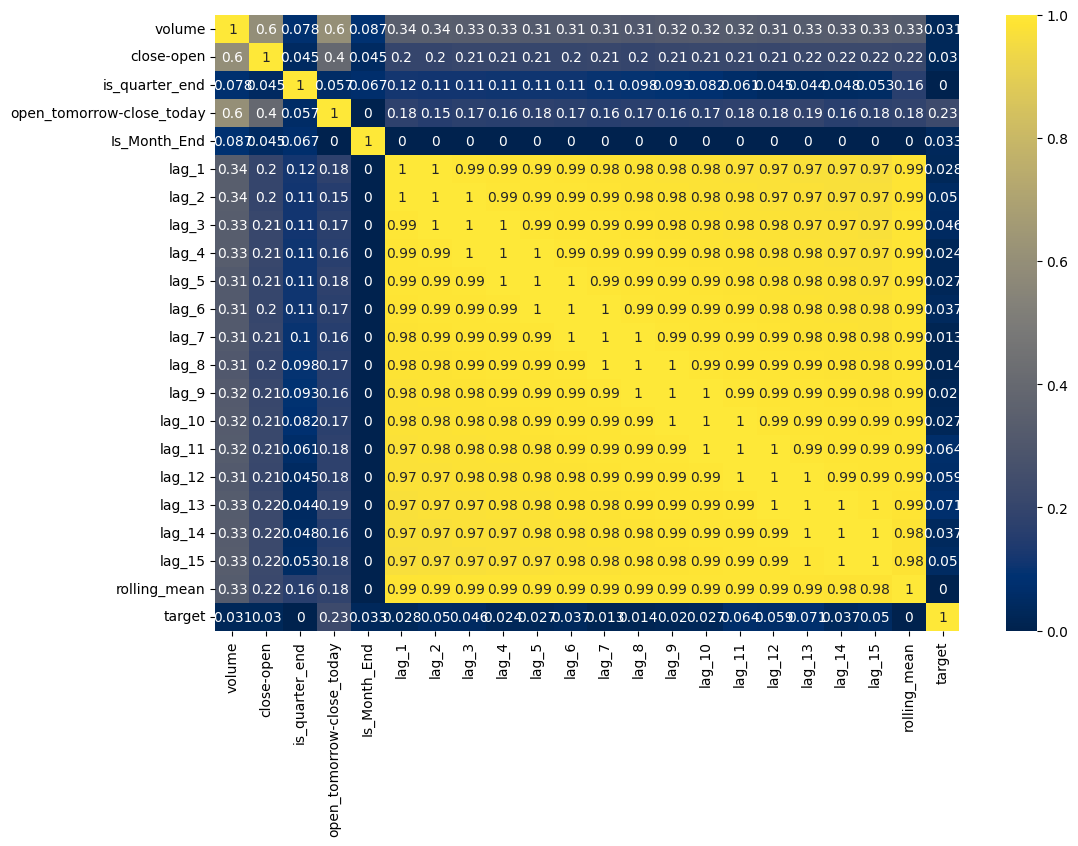

In [ ]:
plt.figure(figsize = (12,8))
sns.heatmap(df2.phik_matrix(
    #interval_cols=interval_cols
    ), annot=True, cmap='cividis')

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df2, 'target')

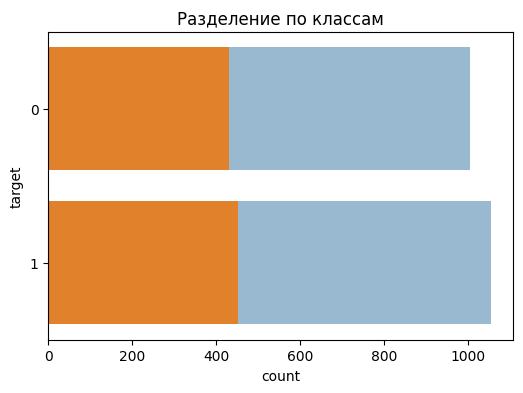

In [ ]:
plot_class_distribution_train_test(y_train, y_test, 'target')

In [ ]:
# Параметры для дерева решений
dt_params = {
    'model__max_features': range(1, 28, 4),
    'model__max_depth': range(1, 20, 4),
    'model__min_samples_leaf': range(2, 5, 1),
    'model__min_samples_split': range(1,8,1),
    }
# Параметры для случайного леса
rf_params = {
    #'model__max_features': range(1, 20, 2),
    'model__max_depth': range(1, 15, 2),
    'model__min_samples_leaf': range(2,12,2),
    'model__min_samples_split': range(2,8,2),
    }
# Параметры для LGBM
lgbm_params = {
    'model___estimators':  range(1, 20, 2),
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__verbosity': [-1]
    }


# Словарь моделей и их параметров
models_params = {
    'DecisionTreeClassifier' : (DecisionTreeClassifier(random_state=RANDOM_STATE), dt_params),
    'RandomForestClassifier' : (RandomForestClassifier(random_state=RANDOM_STATE), rf_params),
    'LGBMClassifier' : (LGBMClassifier(random_state=RANDOM_STATE), lgbm_params),
    }

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)


DecisionTreeClassifier:
Метрика Precision на кросс-валидации: 0.583
Метрика Precision на тесте: 0.587
Метрика ROC AUC на трейне: 0.585
Метрика ROC AUC на тесте: 0.569
Метрика F1 Macro на трейне: 0.561
Метрика F1 Macro на тесте: 0.542
Метрика Recall на трейне: 0.585
Метрика Recall на тесте: 0.569
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 DecisionTreeClassifier(max_depth=1, max_features=21,
                                        min_samples_leaf=2,
                                        random_state=654321))])
----------------------------------------
RandomForestClassifier:
Метрика Precision на кросс-валидации: 0.571
Метрика Precision на тесте: 0.578
Метрика ROC AUC на трейне: 0.741
Метрика ROC AUC на тесте: 0.578
Метрика F1 Macro на трейне: 0.741
Метрика F1 Macro на тесте: 0.578
Метрика Recall на трейне: 0.741
Метрика Recall на тесте: 0.578
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model

In [ ]:
results_data = []
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
0,DecisionTreeClassifier,"(StandardScaler(), DecisionTreeClassifier(max_...","{'model__max_depth': 1, 'model__max_features':...",0.583,0.587,0.585,0.569,0.561,0.542,0.585,0.569
1,RandomForestClassifier,"(StandardScaler(), (DecisionTreeClassifier(max...","{'model__max_depth': 7, 'model__min_samples_le...",0.571,0.578,0.741,0.578,0.741,0.578,0.741,0.578
2,LGBMClassifier,"(StandardScaler(), LGBMClassifier(_estimators=...","{'model___estimators': 1, 'model__learning_rat...",0.563,0.577,0.757,0.577,0.757,0.577,0.757,0.577


In [ ]:
# Параметры для Catboost

catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    #'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass']
    }
'''
catb_params = {
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__depth': [3, 5, 7],
    'model__loss_function': ['Logloss', 'CrossEntropy', 'AUC', 'Multiclass'],
    'model__l2_leaf_reg': [3, 5, 7],  # регуляризация
    'model__iterations': [500, 1000],  # количество итераций
    'model__bootstrap_type': ['Bayesian'],  # тип бутстрапа
    'model__od_wait': [50],  # early stopping
    'model__border_count': [32, 64],  # количество границ для бинаризации
    'model__one_hot_max_size': [5],  # максимальный размер one-hot encoding
}
'''
# Словарь моделей и их параметров
models_params = {
    'CatBoostClassifier' : (CatBoostClassifier(random_state=RANDOM_STATE,
                               iterations=1000,
                               verbose=False
                               ), catb_params)
}

# Вызов функции
best_models_list = find_best_models(X_train, y_train, X_test, y_test, models_params)

CatBoostClassifier:
Метрика Precision на кросс-валидации: 0.579
Метрика Precision на тесте: 0.583
Метрика ROC AUC на трейне: 0.746
Метрика ROC AUC на тесте: 0.583
Метрика F1 Macro на трейне: 0.746
Метрика F1 Macro на тесте: 0.583
Метрика Recall на трейне: 0.746
Метрика Recall на тесте: 0.583
Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e652a690>)])
----------------------------------------


In [ ]:
create_results_dataframe(best_models_list)

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
0,DecisionTreeClassifier,"(StandardScaler(), DecisionTreeClassifier(max_...","{'model__max_depth': 1, 'model__max_features':...",0.583,0.587,0.585,0.569,0.561,0.542,0.585,0.569
1,RandomForestClassifier,"(StandardScaler(), (DecisionTreeClassifier(max...","{'model__max_depth': 7, 'model__min_samples_le...",0.571,0.578,0.741,0.578,0.741,0.578,0.741,0.578
2,LGBMClassifier,"(StandardScaler(), LGBMClassifier(_estimators=...","{'model___estimators': 1, 'model__learning_rat...",0.563,0.577,0.757,0.577,0.757,0.577,0.757,0.577
3,CatBoostClassifier,"(StandardScaler(), <catboost.core.CatBoostClas...","{'model__depth': 5, 'model__learning_rate': 0.01}",0.579,0.583,0.746,0.583,0.746,0.583,0.746,0.583


In [ ]:
find_best_model(results_data)

Лучшая модель: Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e652a690>)])


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 <catboost.core.CatBoostClassifier object at 0x7a64e652a690>)])

In [ ]:
# Сохраняем лучшую модель в файл
save_results(best_model, filename='best_model.pkl')

Результаты сохранены в файл: best_model.pkl


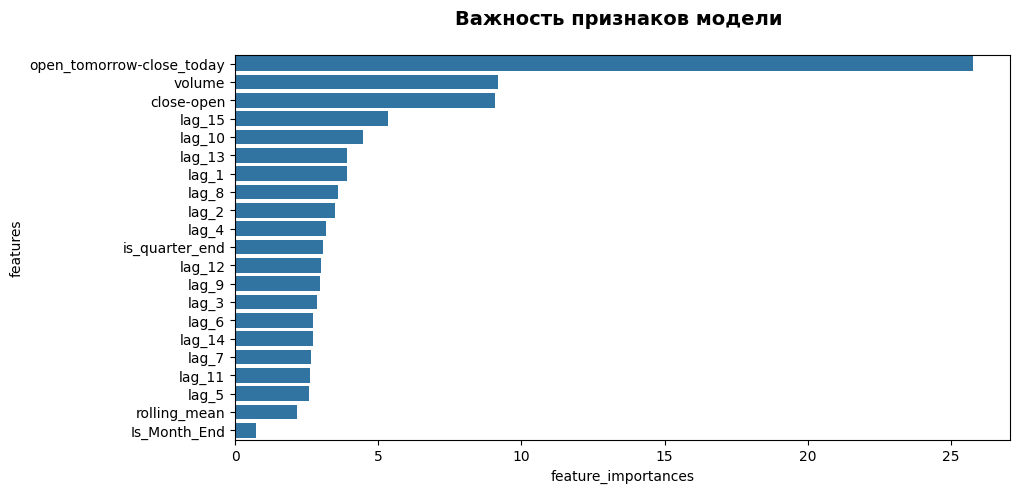

In [ ]:
# Получаем доступ к модели внутри Pipeline
best_model_model = best_model.named_steps['model']

plot_feature_importance(best_model_model, X_test)

In [ ]:
result_df = pd.DataFrame(results_data)

metrics_columns = [
    'PRECISION CV',
    'PRECISION TEST',
    'ROC AUC TRAIN',
    'ROC AUC TEST',
    'F1 TRAIN',
    'F1 TEST',
    'RECALL TRAIN',
    'RECALL TEST'
]
# Преобразуем все столбцы в float
for column in metrics_columns:
    result_df[column] = pd.to_numeric(result_df[column], errors='coerce')

# Находим индекс строки с максимальной метрикой на тесте
best_model_index = np.argmax(result_df['PRECISION CV'] + result_df['ROC AUC TRAIN'])

# Выводим строку с максимальным значением F1 TEST
display(result_df.loc[[best_model_index]])

,Model,Best Model,Best params,PRECISION CV,PRECISION TEST,ROC AUC TRAIN,ROC AUC TEST,F1 TRAIN,F1 TEST,RECALL TRAIN,RECALL TEST
3,CatBoostClassifier,"(StandardScaler(), <catboost.core.CatBoostClas...","{'model__depth': 5, 'model__learning_rate': 0.01}",0.579,0.583,0.746,0.583,0.746,0.583,0.746,0.583


In [ ]:
y_pred = best_model.predict(X_test)

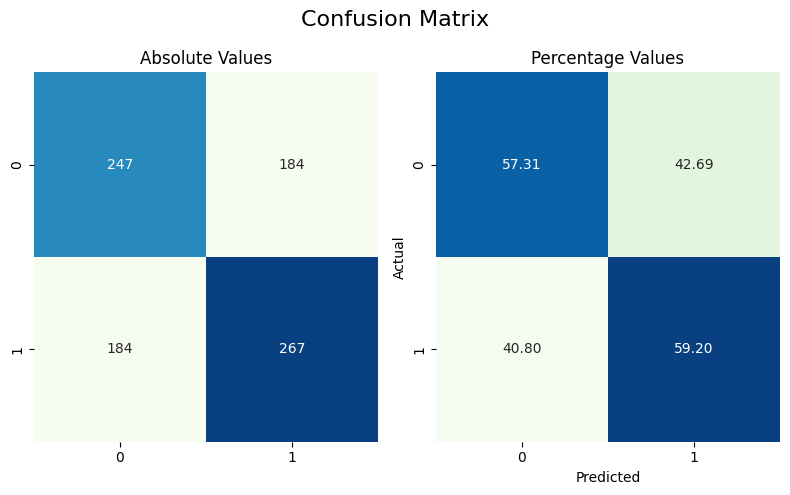

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))

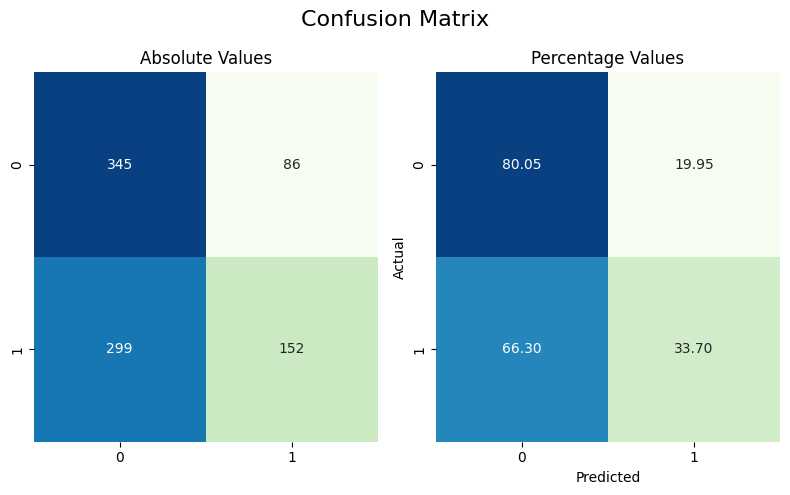

 Confusion matrix created for DecisionTreeClassifier 
--------------------------------------------------


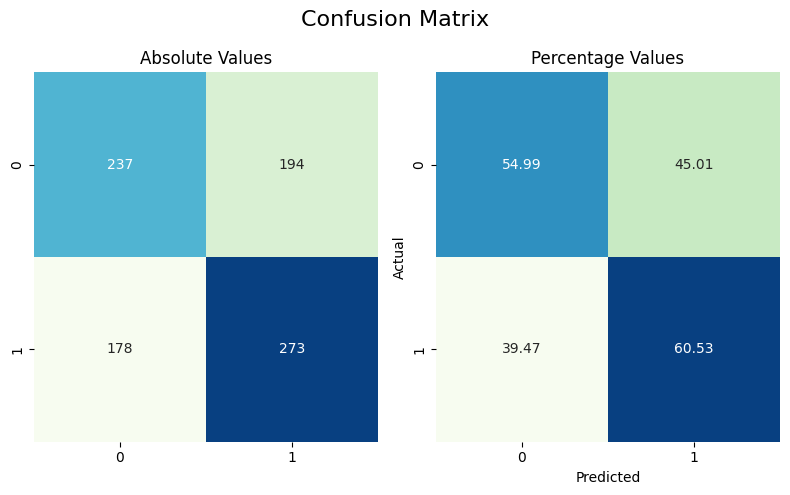

 Confusion matrix created for RandomForestClassifier 
--------------------------------------------------


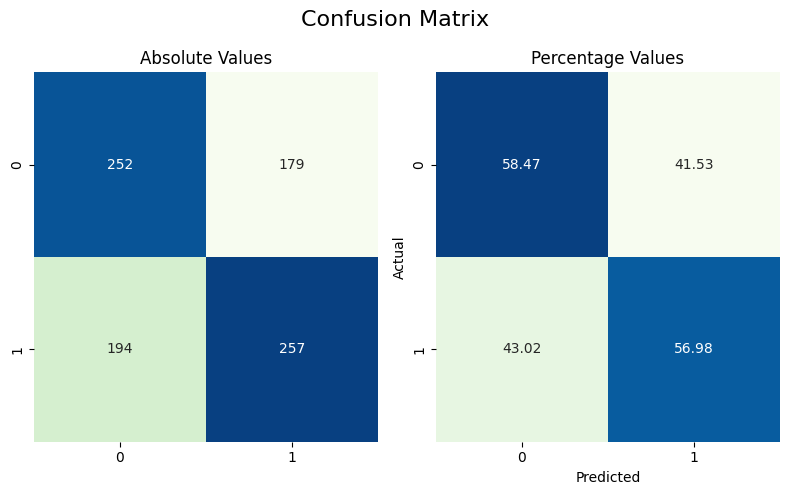

 Confusion matrix created for LGBMClassifier 
--------------------------------------------------


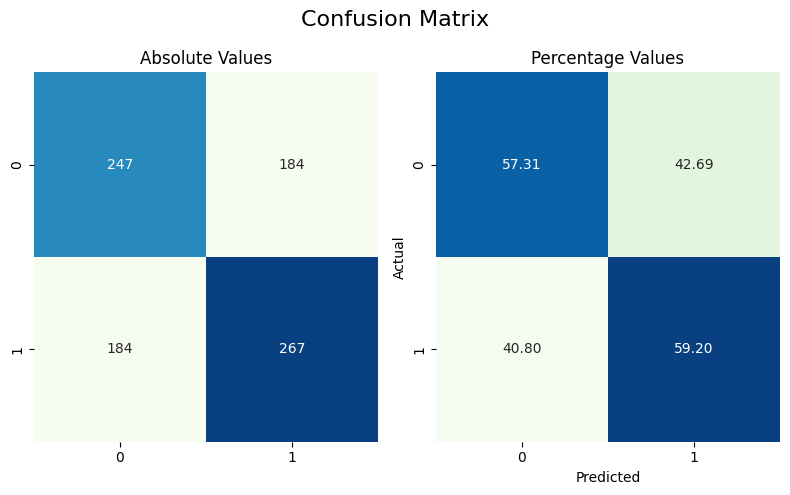

 Confusion matrix created for CatBoostClassifier 
--------------------------------------------------


In [ ]:
matrices = get_matrices(result_df, X_test, y_test, 0, 5)

В данном случае выбрана модель Catboost. Она более-менее уравновешена, хотя, как и в предыдущем случае с подным набором признаков, метрика не доходит даже до 0,6, таким образом, рекомендовать ее к работе нежелательно.

### Стэкинг

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import numpy as np

# Создаем базовые классификаторы
estimators = [
    ('best_model', best_model),  # убедитесь, что best_model определен
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
]

# Создаем финальный классификатор с кросс-валидацией
final_estimator = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
)

# Добавляем расчет precision через кросс-валидацию
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
precision_cv = cross_val_score(final_estimator, X_train, y_train,
                              cv=cv, scoring='precision_macro', n_jobs=-1)

# Создаем стекинг классификатор
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator,
    cv=5,  # добавляем кросс-валидацию
    n_jobs=-1  # используем все доступные ядра
)

# Обучаем модель
stack_clf.fit(X_train, y_train)

# Метрики на тренировочном наборе
y_pred_train = stack_clf.predict(X_train)
y_pred_proba_train = stack_clf.predict_proba(X_train)

# Метрики на тестовом наборе
y_pred = stack_clf.predict(X_test)
y_pred_proba = stack_clf.predict_proba(X_test)

# Вычисляем метрики
precision_train = precision_score(y_train, y_pred_train, average='macro')
precision_test = precision_score(y_test, y_pred, average='macro')

recall_train = recall_score(y_train, y_pred_train, average='macro')
recall_test = recall_score(y_test, y_pred, average='macro')

f1_train = f1_score(y_train, y_pred_train, average='macro')
f1_test = f1_score(y_test, y_pred, average='macro')

roc_auc_train = roc_auc_score(y_train, y_pred_train, average='macro')
roc_auc_test = roc_auc_score(y_test, y_pred, average='macro')

# Выводим результаты
print(f"Precision (CV): {np.mean(precision_cv):.3f} ± {np.std(precision_cv):.3f}")
print(f"Precision (Test): {precision_test:.3f}")

print(f"Recall (Train): {recall_train:.3f}")
print(f"Recall (Test): {recall_test:.3f}")

print(f"F1 Score (Train): {f1_train:.3f}")
print(f"F1 Score (Test): {f1_test:.3f}")

print(f"ROC AUC (Train): {roc_auc_train:.3f}")
print(f"ROC AUC (Test): {roc_auc_test:.3f}")


Precision (CV): 0.581 ± 0.030
Precision (Test): 0.597
Recall (Train): 0.632
Recall (Test): 0.597
F1 Score (Train): 0.632
F1 Score (Test): 0.596
ROC AUC (Train): 0.632
ROC AUC (Test): 0.597


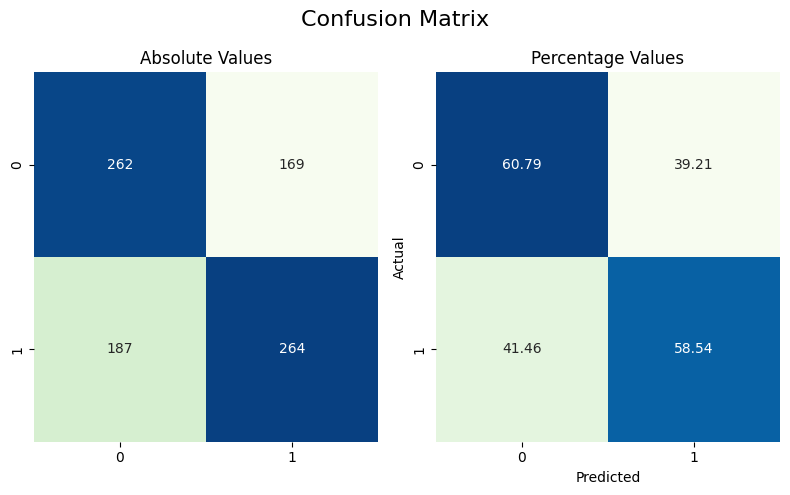

In [ ]:
plot_confusion_matrix(y_test, y_pred, figsize=(4, 5))

Используя стекинг, мы смогли добиться того, чтобы приблизить метрику к 0,6, матрица стала лучше и по итогам данной работы имеет смысл рекомендовать именно данную модель.

## Нейросети

In [ ]:
import random
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras.metrics import Precision, Recall, AUC

In [ ]:
# Устанавливаем фиксированные семена
def set_seeds(seed=RANDOM_STATE):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df2, 'target')

Epoch 1/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - auc: 0.5117 - loss: 1.0755 - precision: 0.5340 - recall: 0.4497 - val_auc: 0.5360 - val_loss: 0.9015 - val_precision: 0.5358 - val_recall: 0.9819 - learning_rate: 1.0000e-04
Epoch 2/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - auc: 0.5078 - loss: 1.0350 - precision: 0.5235 - recall: 0.4751 - val_auc: 0.5290 - val_loss: 0.8616 - val_precision: 0.5356 - val_recall: 0.9864 - learning_rate: 1.0000e-04
Epoch 3/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.5058 - loss: 1.0323 - precision: 0.5202 - recall: 0.4570 - val_auc: 0.5399 - val_loss: 0.8555 - val_precision: 0.5356 - val_recall: 0.9864 - learning_rate: 1.0000e-04
Epoch 4/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.5242 - loss: 1.0059 - precision: 0.5506 - recall: 0.4950 - val_auc: 0.5397 - val_loss: 0.8487 - val_precision: 0.5371 - val_recall: 0.9819 - learning_rate: 1.0000e-04
Epoch 5/200
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - auc: 0.5242 - loss: 0.9840 - precision

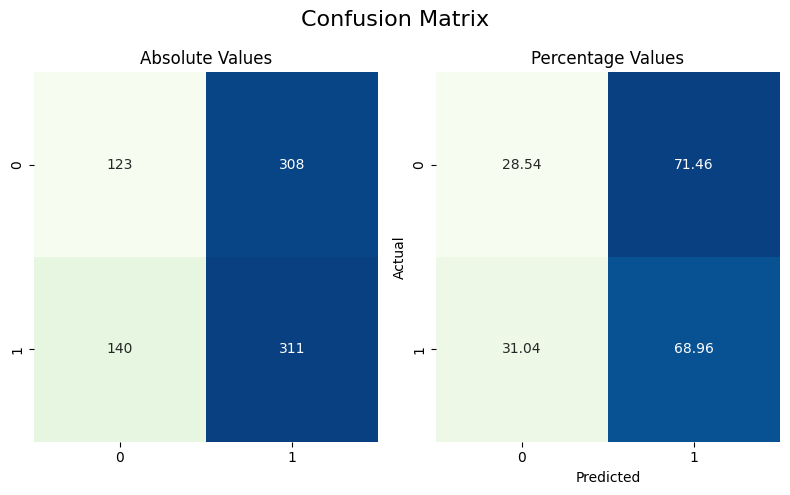

In [ ]:
set_seeds()

# Создание модели
model = Sequential()
model.add(Dense(128, input_dim=X_train.shape[1],
                activation='relu',
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu',
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32, activation='relu',
                kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
opt = Adam(learning_rate=0.0001)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                             patience=10, min_lr=0.000001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20)

model.compile(optimizer=opt,
              loss='binary_crossentropy',
              metrics=[Precision(),
                       Recall(),
                       AUC()
                       ])

# Обучение модели
history = model.fit(X_train, y_train,
                    epochs=200,
                    batch_size=64,
                    validation_split=0.2,
                    callbacks=[reduce_lr, early_stop],
                    verbose=1)

# Получаем предсказания
y_pred = model.predict(X_test)
y_pred_classes = np.round(y_pred)

plot_confusion_matrix(y_test, y_pred_classes, figsize=(4, 5))

Нейросеть в данном случае не справилась с задачей. Матрица ошибок похожа на простую dummy-модель, что говорит о том, что нейросеть не угадывает, а скорее назначает результат в мажоритарный класс.
Причина, вероятнее всего, в недостаточности данных. Таким образом, рекомендовать нейросеть нецелесообразно задаче.

## Расчет прибыли/потерь

### Рассчитаем прибыли и потери при работе лучшей моделью.

In [ ]:
columns = ['low', 'high', 'numtrades', 'value', 'legalcloseprice', 'waprice',
           'marketprice2', 'marketprice3', 'mp2valtrd', 'marketprice3tradesvalue',
           'tradingsession', 'trendclspr', 'day_of_week', 'day_of_month',
           'month', 'year', 'high-low', 'RSI', 'MACD', 'MACD_Signal', 'SMA_5',
           'EMA_20', 'Daily_Return', 'Log_Return', 'Is_Weekend', 'Volume_MA',
           'units' ]
df3 = df.drop(columns, axis=1)

In [ ]:
df3 = move_column_to_end(df3, 'target')

In [ ]:
X_train, X_test, y_train, y_test = split_data_res_ind(df3, 'target')

In [ ]:
X_test_df = pd.DataFrame(X_test)
display(X_test_df.head())



,open,close,volume,close-open,is_quarter_end,open_tomorrow-close_today,Is_Month_End,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean
0,6784.0,6739.0,279875,-45.0,1,35.0,False,6767.0,6768.0,6771.0,6744.0,6732.5,6702.0,6735.0,6709.0,6723.5,6560.0,6860.0,7043.5,7014.5,6977.0,7140.0,6816.466667
1,5410.5,4650.0,4692673,-760.5,0,-250.0,False,6020.0,5810.0,6456.5,6733.0,6970.0,6979.0,6796.0,6707.5,6984.5,6973.5,6957.5,6988.0,7010.0,6865.5,7040.0,6752.733333
2,6255.0,6138.5,1232327,-116.5,0,1.5,False,6239.5,6347.0,6385.0,6444.5,6448.5,6408.5,6410.5,6505.0,6447.0,6417.5,6591.0,6687.0,6759.5,6805.5,6727.5,6508.233333
3,2095.0,2062.9,809144,-32.1,0,-0.9,False,2089.9,2110.0,2063.9,2036.0,2021.0,2028.6,2037.4,2099.1,2082.6,2100.0,2112.1,2126.9,2130.0,2149.0,2097.9,2085.626667
4,2045.5,2030.9,745743,-14.6,0,-0.6,False,2042.0,2029.1,2040.7,2049.0,2039.3,2023.0,2028.2,2015.5,1988.1,1975.1,1969.1,1965.0,1970.1,1966.8,1989.0,2006.000000


In [ ]:
X_train = X_train.drop(['open', 'close'], axis=1)
X_test = X_test.drop(['open', 'close'], axis=1)

In [ ]:
# Добавляем столбец для предсказаний модели
X_test_df['predictions'] = best_model.predict(X_test)

# Теперь можно использовать эти предсказания для дальнейших расчетов:
X_test_df['profit'] = 0

# Начинаем цикл с 1, так как для первого дня нет предыдущего предсказания
for i in range(1, len(X_test_df)):
    try:
        # Используем предсказание за предыдущий день
        if X_test_df.iloc[i-1]['predictions'] == 1:  # если вчерашнее предсказание = 1 (покупать)
            # Рассчитываем количество акций, которые можно купить
            quantity = 100000 / X_test_df.iloc[i]['open']  # используем цену открытия текущего дня

            # Рассчитываем прибыль/убыток
            profit = quantity * X_test_df.iloc[i]['close-open']
            X_test_df.at[i, 'profit'] = profit
    except ZeroDivisionError:
        print(f"Ошибка деления на ноль в строке {i}")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

# Добавляем итоговую прибыль/убыток
X_test_df['cumulative_profit'] = X_test_df['profit'].cumsum()

In [ ]:
display(X_test_df.head())
display(X_test_df.tail())

,open,close,volume,close-open,is_quarter_end,open_tomorrow-close_today,Is_Month_End,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean,predictions,profit,cumulative_profit
0,6784.0,6739.0,279875,-45.0,1,35.0,False,6767.0,6768.0,6771.0,6744.0,6732.5,...,6709.0,6723.5,6560.0,6860.0,7043.5,7014.5,6977.0,7140.0,6816.466667,1,0.000000,0.000000
1,5410.5,4650.0,4692673,-760.5,0,-250.0,False,6020.0,5810.0,6456.5,6733.0,6970.0,...,6707.5,6984.5,6973.5,6957.5,6988.0,7010.0,6865.5,7040.0,6752.733333,0,-14056.002218,-14056.002218
2,6255.0,6138.5,1232327,-116.5,0,1.5,False,6239.5,6347.0,6385.0,6444.5,6448.5,...,6505.0,6447.0,6417.5,6591.0,6687.0,6759.5,6805.5,6727.5,6508.233333,0,0.000000,-14056.002218
3,2095.0,2062.9,809144,-32.1,0,-0.9,False,2089.9,2110.0,2063.9,2036.0,2021.0,...,2099.1,2082.6,2100.0,2112.1,2126.9,2130.0,2149.0,2097.9,2085.626667,0,0.000000,-14056.002218
4,2045.5,2030.9,745743,-14.6,0,-0.6,False,2042.0,2029.1,2040.7,2049.0,2039.3,...,2015.5,1988.1,1975.1,1969.1,1965.0,1970.1,1966.8,1989.0,2006.000000,0,0.000000,-14056.002218


,open,close,volume,close-open,is_quarter_end,open_tomorrow-close_today,Is_Month_End,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean,predictions,profit,cumulative_profit
877,5378.0,5345.5,611671,-32.5,0,0.5,False,5372.0,5378.5,5305.0,5380.0,5358.5,...,5338.0,5320.0,5245.0,5230.0,5190.0,5178.5,5210.5,5237.0,5288.166667,0,-604.313871,27040.196354
878,1915.0,1893.9,12015,-21.1,0,6.6,False,1892.3,1899.4,1886.0,1934.4,1920.0,...,1924.3,1942.8,1966.9,1978.9,2002.2,1978.2,2003.4,1993.2,1948.680000,1,0.000000,27040.196354
879,2730.0,2785.0,593550,55.0,0,2.0,False,2738.0,2806.0,2842.5,2815.0,2839.5,...,2886.0,2867.0,2887.0,2836.5,2821.0,2829.0,2855.0,2858.0,2830.566667,1,2014.652015,29054.848369
880,4181.5,4140.0,778022,-41.5,1,-20.0,False,4159.5,4191.0,4159.5,4250.0,4264.5,...,4205.5,4209.0,4246.5,4224.0,4290.0,4248.0,4230.0,4263.0,4234.500000,0,-992.466818,28062.381551
881,2460.0,2465.0,1051834,5.0,0,0.0,False,2460.0,2425.3,2455.0,2429.2,2469.9,...,2406.0,2445.0,2469.0,2487.0,2474.4,2476.0,2475.0,2500.3,2452.120000,0,0.000000,28062.381551


Итак, при использовании лучшей модели прибыль за 881 сделку составит 28062 рубля.

Это ниже ставки ЦБ.
Работать с данной моделью невыгодно.

### Рассчитаем прибыль в случае использования стекинг-модели

In [ ]:
# Добавляем столбец для предсказаний модели
X_test_df['predictions'] = stack_clf.predict(X_test)

# Теперь можно использовать эти предсказания для дальнейших расчетов:
X_test_df['profit'] = 0

# Начинаем цикл с 1, так как для первого дня нет предыдущего предсказания
for i in range(1, len(X_test_df)):
    try:
        # Используем предсказание за предыдущий день
        if X_test_df.iloc[i-1]['predictions'] == 1:  # если вчерашнее предсказание = 1 (покупать)
            # Рассчитываем количество акций, которые можно купить
            quantity = 100000 / X_test_df.iloc[i]['open']  # используем цену открытия текущего дня

            # Рассчитываем прибыль/убыток
            profit = quantity * X_test_df.iloc[i]['close-open']
            X_test_df.at[i, 'profit'] = profit
    except ZeroDivisionError:
        print(f"Ошибка деления на ноль в строке {i}")
    except Exception as e:
        print(f"Произошла ошибка: {e}")

# Добавляем итоговую прибыль/убыток
X_test_df['cumulative_profit'] = X_test_df['profit'].cumsum()

In [ ]:
display(X_test_df.head())
display(X_test_df.tail())

,open,close,volume,close-open,is_quarter_end,open_tomorrow-close_today,Is_Month_End,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean,predictions,profit,cumulative_profit
0,6784.0,6739.0,279875,-45.0,1,35.0,False,6767.0,6768.0,6771.0,6744.0,6732.5,...,6709.0,6723.5,6560.0,6860.0,7043.5,7014.5,6977.0,7140.0,6816.466667,1,0.000000,0.000000
1,5410.5,4650.0,4692673,-760.5,0,-250.0,False,6020.0,5810.0,6456.5,6733.0,6970.0,...,6707.5,6984.5,6973.5,6957.5,6988.0,7010.0,6865.5,7040.0,6752.733333,0,-14056.002218,-14056.002218
2,6255.0,6138.5,1232327,-116.5,0,1.5,False,6239.5,6347.0,6385.0,6444.5,6448.5,...,6505.0,6447.0,6417.5,6591.0,6687.0,6759.5,6805.5,6727.5,6508.233333,0,0.000000,-14056.002218
3,2095.0,2062.9,809144,-32.1,0,-0.9,False,2089.9,2110.0,2063.9,2036.0,2021.0,...,2099.1,2082.6,2100.0,2112.1,2126.9,2130.0,2149.0,2097.9,2085.626667,0,0.000000,-14056.002218
4,2045.5,2030.9,745743,-14.6,0,-0.6,False,2042.0,2029.1,2040.7,2049.0,2039.3,...,2015.5,1988.1,1975.1,1969.1,1965.0,1970.1,1966.8,1989.0,2006.000000,0,0.000000,-14056.002218


,open,close,volume,close-open,is_quarter_end,open_tomorrow-close_today,Is_Month_End,lag_1,lag_2,lag_3,lag_4,lag_5,...,lag_8,lag_9,lag_10,lag_11,lag_12,lag_13,lag_14,lag_15,rolling_mean,predictions,profit,cumulative_profit
877,5378.0,5345.5,611671,-32.5,0,0.5,False,5372.0,5378.5,5305.0,5380.0,5358.5,...,5338.0,5320.0,5245.0,5230.0,5190.0,5178.5,5210.5,5237.0,5288.166667,0,-604.313871,25032.766369
878,1915.0,1893.9,12015,-21.1,0,6.6,False,1892.3,1899.4,1886.0,1934.4,1920.0,...,1924.3,1942.8,1966.9,1978.9,2002.2,1978.2,2003.4,1993.2,1948.680000,1,0.000000,25032.766369
879,2730.0,2785.0,593550,55.0,0,2.0,False,2738.0,2806.0,2842.5,2815.0,2839.5,...,2886.0,2867.0,2887.0,2836.5,2821.0,2829.0,2855.0,2858.0,2830.566667,1,2014.652015,27047.418383
880,4181.5,4140.0,778022,-41.5,1,-20.0,False,4159.5,4191.0,4159.5,4250.0,4264.5,...,4205.5,4209.0,4246.5,4224.0,4290.0,4248.0,4230.0,4263.0,4234.500000,0,-992.466818,26054.951565
881,2460.0,2465.0,1051834,5.0,0,0.0,False,2460.0,2425.3,2455.0,2429.2,2469.9,...,2406.0,2445.0,2469.0,2487.0,2474.4,2476.0,2475.0,2500.3,2452.120000,0,0.000000,26054.951565


При работе со стекинг-моделью мы можем получить прибыль 26 тыс за 881 сделку, что тоже не является выгодным и выглядит ниже инфляции.

# **Результаты исследования**
В ходе проведенного анализа установлено, что построение эффективной модели классификации направления движения цен (рост/падение) на следующий период является нецелесообразным.

**Факторы, ограничивающие качество классификации**
- Рыночные особенности
- Высокая степень неопределенности рыночных процессов
- Влияние множества внешних факторов, не поддающихся количественной оценке
- Эмоциональные реакции участников рынка, искажающие ценовые паттерны
- Ограничения данных
- Недостаточная репрезентативность выборки для обучения модели
- Отсутствие устойчивых признаков, позволяющих достоверно классифицировать направление движения
- Быстрое изменение статистических характеристик рынка

**Методологические ограничения**
- Невозможность учета всех релевантных признаков в рамках выбранной модели
- Сложность выявления значимых закономерностей в данных
- Высокая степень зашумленности ценовых сигналов

**Анализ причин низкой эффективности классификации**

- Сложность выявления значимых признаков для каждого класса
- Отсутствие устойчивых индикаторов направления движения
- Высокая корреляция между признаками
- Недостаточная информативность входных данных

**Рекомендации по дальнейшим действиям**
1. Сместить фокус с бинарной классификации на:
- Многоклассовую классификацию диапазонов изменения цен
- Прогнозирование вероятности различных сценариев
- Классификацию зон повышенной волатильности
2. Улучшить качество входных данных:
- Расширить набор признаков
- Применить методы отбора наиболее информативных признаков
- Использовать дополнительные источники данных

**Заключительные положения**

Несмотря на неудовлетворительные результаты классификации, это не означает бесполезность аналитических инструментов. Альтернативные подходы могут быть использованы для:
- Оценки вероятности различных сценариев движения цен
- Выявления потенциально рискованных периодов
- Формирования торговых сигналов
- Оптимизации структуры портфеля

Рекомендуется сосредоточиться на разработке комплексных решений, сочетающих:
- Статистические методы анализа
- Фундаментальный анализ
- Технические индикаторы
- Управление рисками

Вместо поиска идеальной модели классификации, следует развивать гибридные подходы к анализу рынка, учитывающие его многогранность и непредсказуемость.